In [ ]:
# ============================================================
# 0) Importar librerías y configurar entorno
# ============================================================
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ============================================================
# 1) Cargar la base SQLite
# ============================================================
from google.colab import files

# Cargar archivo .sqlite desde el equipo local
archivos = files.upload()

# Identificar el archivo SQLite cargado
ruta_sqlite = [n for n in archivos.keys() if n.lower().endswith(".sqlite")][0]
print("Archivo SQLite cargado:", ruta_sqlite)

# ============================================================
# 2) Conectar a la base y verificar tablas
# ============================================================
conexion = sqlite3.connect(ruta_sqlite)

tablas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conexion)
print("Tablas encontradas:")
display(tablas)

# Verificar columnas de la tabla principal
df_columnas = pd.read_sql_query("PRAGMA table_info(lecturas);", conexion)
print("Columnas en 'lecturas':")
display(df_columnas)


Saving QDBR.sqlite to QDBR.sqlite
Archivo SQLite cargado: QDBR.sqlite
Tablas encontradas:


,name
0,lecturas


Columnas en 'lecturas':


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,1,None,1
1,1,fecha,TEXT,0,None,0
2,2,T1,REAL,0,NULL,0
3,3,T2,REAL,0,NULL,0
4,4,T3,REAL,0,NULL,0
5,5,T4,REAL,0,NULL,0
6,6,T5,REAL,0,NULL,0
7,7,H1,REAL,0,NULL,0
8,8,H2,REAL,0,NULL,0
9,9,H3,REAL,0,NULL,0


In [ ]:
# ============================================================
# 3) Extraer datos necesarios desde SQL
# ============================================================
consulta_datos = """
SELECT
  fecha,
  T2, T3, T4,
  RH,
  VPD,
  AH,
  DP,
  A1, A2, A3, A4,
  A5, A6, A7, A8, A9, A10,
  A11, A12,
  HA10
FROM lecturas
"""

df = pd.read_sql_query(consulta_datos, conexion)

# Convertir fecha a datetime y ordenar
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha").reset_index(drop=True)

# Calcular temperatura media interior
df["T_prom_int"] = (df["T2"] + df["T3"] + df["T4"]) / 3.0

print("Vista rápida de los datos extraídos:")
display(df.head())

Vista rápida de los datos extraídos:


,fecha,T2,T3,T4,RH,VPD,AH,DP,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,HA10,T_prom_int
0,2025-09-27 15:41:43,23.4,21.0,22.2,65.73,0.92,12.90,15.49,1,0,0,0,0,0,0,0,0,0,0,1,0,22.200000
1,2025-09-27 15:42:43,23.8,21.0,22.2,65.77,0.92,13.01,15.62,0,0,0,0,0,0,0,0,0,0,0,0,0,22.333333
2,2025-09-27 15:43:44,24.2,21.4,22.5,66.43,0.93,13.42,16.13,0,0,0,0,0,0,0,0,0,0,0,0,0,22.700000
3,2025-09-27 15:44:44,24.8,21.9,23.0,64.20,1.02,13.37,16.10,1,1,0,0,0,0,0,0,0,0,0,1,0,23.233333
4,2025-09-27 15:45:44,25.4,22.2,23.3,66.53,0.98,14.18,17.04,1,1,0,0,0,0,0,0,0,0,0,1,0,23.633333


In [ ]:
# ============================================================
# 4) Preparación del dataset
#     Sincronizar temporalmente (resample + LOCF actuadores)
#     Depurar (aplicar rangos, detectar atípicos, diagnosticar huecos, imputar huecos cortos)
#     Recalcular psicrometría (auditar consistencia) y armonizar unidades de AH a g/m³
#     Particionar temporalmente (train/val/test + purge gap)
# ============================================================

# ---------- Parámetros ----------
umbral_hueco_seg = 300                 # Definir umbral de hueco grande (segundos)
ventana_hampel = 7                     # Definir ventana del filtro Hampel (puntos)
sigma_hampel = 3.0                     # Definir umbral Hampel (sigmas)
imputacion_lineal_max_hueco = 2        # Definir máximo de pasos consecutivos imputables por interpolación

# Definir rangos físicos plausibles (marcar fuera de rango como NaN)
rangos = {
    "T_prom_int": (-5.0, 60.0),
    "RH": (0.0, 100.0),
    "VPD": (0.0, 5.0),
    "AH": (0.0, 40.0),                 # Mantener como referencia operativa en g/m³
    "DP": (-20.0, 60.0),
}

# Definir horizonte máximo (minutos) para purge gap
horizonte_max_min = 60

# ---------- Funciones ----------
def inferir_frecuencia_resample(serie_fechas: pd.Series) -> str:
    """Inferir frecuencia nominal de muestreo a partir de la mediana del delta temporal."""
    dt = serie_fechas.sort_values().diff().dropna()
    if dt.empty:
        return "5min"
    seg = int(round(dt.median().total_seconds()))
    if seg <= 60:
        return "1min"
    if seg <= 300:
        return "5min"
    if seg <= 600:
        return "10min"
    return f"{seg}S"

def aplicar_rangos(df_in: pd.DataFrame, rangos_in: dict) -> pd.DataFrame:
    """Marcar como NaN los valores fuera de rango físico plausible."""
    out = df_in.copy()
    for col, (lo, hi) in rangos_in.items():
        if col in out.columns:
            out.loc[(out[col] < lo) | (out[col] > hi), col] = np.nan
    return out

def hampel_filtro(x: pd.Series, ventana: int = 7, n_sigmas: float = 3.0) -> pd.Series:
    """Detectar atípicos con Hampel y reemplazarlos por NaN."""
    if x.isna().all() or len(x) < ventana:
        return x
    k = 1.4826
    mediana = x.rolling(ventana, center=True).median()
    mad = (x - mediana).abs().rolling(ventana, center=True).median()
    umbral = n_sigmas * k * mad
    outlier = (x - mediana).abs() > umbral
    y = x.copy()
    y[outlier] = np.nan
    return y

def diagnostico_huecos(df_in: pd.DataFrame, umbral_seg: int) -> pd.DataFrame:
    """Identificar huecos temporales mayores al umbral (segundos)."""
    fechas = df_in["fecha"].sort_values().reset_index(drop=True)
    delta = fechas.diff().dt.total_seconds()
    mask = delta > umbral_seg
    huecos = pd.DataFrame(
        {"fecha_inicio": fechas.shift(1), "fecha_fin": fechas, "delta_seg": delta}
    )[mask].reset_index(drop=True)
    return huecos

def calcular_psicrometria_desde_T_RH(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Recalcular psicrometría desde T_prom_int y RH:
      - es(T) por Tetens (kPa)
      - ea = es * RH/100 (kPa)
      - VPD = es - ea (kPa)
      - AH (g/m³) desde ea y T (armonizar unidades)
      - DP (°C) por Magnus (aprox.)
    """
    out = df_in.copy()
    T = out["T_prom_int"].astype(float)
    RH_ = out["RH"].astype(float)

    # Calcular presiones de vapor en kPa
    es = 0.6108 * np.exp((17.27 * T) / (T + 237.3))        # kPa
    ea = es * (RH_ / 100.0)                                # kPa
    vpd = es - ea                                          # kPa

    # Calcular humedad absoluta en g/m³ (convertir ea de kPa a hPa)
    T_K = T + 273.15
    ea_hPa = ea * 10.0                                     # hPa
    ah = 216.7 * ea_hPa / T_K                              # g/m³

    # Calcular punto de rocío (Magnus)
    a, b = 17.27, 237.3
    gamma = (a * T / (b + T)) + np.log(np.clip(RH_, 1e-6, 100.0) / 100.0)
    dp = (b * gamma) / (a - gamma)

    out["VPD_calc"] = vpd
    out["AH_calc"] = ah
    out["DP_calc"] = dp
    out["delta_rocio_calc"] = out["T_prom_int"] - out["DP_calc"]
    return out

def reporte_consistencia(df_in: pd.DataFrame) -> pd.DataFrame:
    """Cuantificar consistencia entre variables registradas y recalculadas (MAE y sesgo)."""
    filas = []
    for var in ["VPD", "AH", "DP"]:
        if var in df_in.columns and f"{var}_calc" in df_in.columns:
            d = df_in[var] - df_in[f"{var}_calc"]
            filas.append(
                {
                    "variable": var,
                    "mae": float(np.nanmean(np.abs(d))),
                    "sesgo_medio": float(np.nanmean(d)),
                    "n": int(np.sum(~np.isnan(d))),
                }
            )
    return pd.DataFrame(filas)

def particionar_temporal(
    df_in: pd.DataFrame,
    fr_train: float = 0.70,
    fr_val: float = 0.15,
    fr_test: float = 0.15,
    purge_gap_pasos: int = 12,
):
    """Particionar por tiempo y aplicar purge gap por índices para evitar fuga de información."""
    assert abs(fr_train + fr_val + fr_test - 1.0) < 1e-6
    df_ord = df_in.sort_values("fecha").reset_index(drop=True)
    n = len(df_ord)

    i_train = int(np.floor(n * fr_train))
    i_val = int(np.floor(n * (fr_train + fr_val)))

    i_train_fin = max(0, i_train - purge_gap_pasos)
    i_val_ini = min(n, i_train + purge_gap_pasos)
    i_val_fin = max(0, i_val - purge_gap_pasos)
    i_test_ini = min(n, i_val + purge_gap_pasos)

    df_train = df_ord.iloc[:i_train_fin].copy()
    df_val = df_ord.iloc[i_val_ini:i_val_fin].copy()
    df_test = df_ord.iloc[i_test_ini:].copy()

    cortes = {
        "n_train": len(df_train),
        "n_val": len(df_val),
        "n_test": len(df_test),
        "corte_train_bruto": df_ord.loc[i_train, "fecha"] if i_train < n else df_ord["fecha"].max(),
        "corte_val_bruto": df_ord.loc[i_val, "fecha"] if i_val < n else df_ord["fecha"].max(),
        "purge_gap_pasos": purge_gap_pasos,
    }
    return df_train, df_val, df_test, cortes


# ============================================================
# 4.2.1 Sincronizar temporalmente
# ============================================================

frecuencia_resample = inferir_frecuencia_resample(df["fecha"])
print("Frecuencia resample inferida:", frecuencia_resample)

df_idx = df.set_index("fecha")

# Identificar actuadores y variables continuas
cols_act = [c for c in df.columns if c.startswith("A")] + (["HA10"] if "HA10" in df.columns else [])
cols_cont = [c for c in df.columns if c not in cols_act + ["fecha"]]

# Resamplear continuas con media y actuadores con último valor + persistencia (LOCF)
df_cont = df_idx[cols_cont].resample(frecuencia_resample).mean()
df_act = df_idx[cols_act].resample(frecuencia_resample).last().ffill()

df_sync = pd.concat([df_cont, df_act], axis=1).reset_index()


# ============================================================
# 4.2.2 Depurar y controlar calidad
# ============================================================

# Marcar fuera de rango
df_clean = aplicar_rangos(df_sync, rangos)

# Detectar atípicos en variables clave
vars_clave = [v for v in ["T_prom_int", "RH", "VPD", "AH", "DP"] if v in df_clean.columns]
for v in vars_clave:
    df_clean[v] = hampel_filtro(df_clean[v], ventana=ventana_hampel, n_sigmas=sigma_hampel)

# Diagnosticar huecos grandes (sobre rejilla sincronizada)
huecos_grandes = diagnostico_huecos(df_clean, umbral_hueco_seg)
print("Huecos grandes detectados:", len(huecos_grandes))
display(huecos_grandes.head())

# Imputar huecos cortos en variables continuas
df_clean = df_clean.set_index("fecha")
for v in vars_clave:
    df_clean[v] = df_clean[v].interpolate(method="time", limit=imputacion_lineal_max_hueco)
df_clean = df_clean.reset_index()

# Calcular margen al punto de rocío (variable registrada)
df_clean["delta_rocio"] = df_clean["T_prom_int"] - df_clean["DP"]


# ============================================================
# 4.2.3 Recalcular psicrometría y auditar consistencia
# ============================================================

df_psico = calcular_psicrometria_desde_T_RH(df_clean)

# Definir AH_gm3 como referencia operativa en g/m³
df_psico["AH_gm3"] = df_psico["AH"]

# Calcular ratio de escala entre AH_gm3 y AH_calc (ambas en g/m³)
ratio_ah = np.nanmedian(df_psico["AH_gm3"]) / np.nanmedian(df_psico["AH_calc"])
print("Ratio mediana(AH_gm3) / mediana(AH_calc):", ratio_ah)

# Reportar consistencia registrada vs recalculada (auditoría)
rep_psico = reporte_consistencia(df_psico)
print("Consistencia (registrado vs recalculado):")
display(rep_psico)

# Reportar consistencia específica de AH en g/m³
d_ah = df_psico["AH_gm3"] - df_psico["AH_calc"]
print("Consistencia AH_gm3 vs AH_calc -> MAE:", float(np.nanmean(np.abs(d_ah))), "| sesgo:", float(np.nanmean(d_ah)))

# Definir dataset mínimo para microclima usando AH en g/m³
columnas_minimas = ["T_prom_int", "RH", "VPD", "AH_gm3", "DP"]
df_microclima = df_psico.dropna(subset=columnas_minimas).copy()

# Calcular delta_rocio operativo (mantener coherencia con DP registrada)
df_microclima["delta_rocio"] = df_microclima["T_prom_int"] - df_microclima["DP"]

print("Resumen 4.2:")
print("Registros sincronizados:", len(df_sync))
print("Registros depurados:", len(df_clean))
print("Registros microclima (mínimos completos):", len(df_microclima))
print("Rango temporal:", df_microclima["fecha"].min(), "->", df_microclima["fecha"].max())


# ============================================================
# 4.2.4 Particionar temporalmente (purge gap)
# ============================================================

delta_min = pd.to_timedelta(frecuencia_resample).total_seconds() / 60.0
purge_gap_pasos = int(np.ceil(horizonte_max_min / delta_min))
print("purge_gap_pasos:", purge_gap_pasos)

df_train, df_val, df_test, cortes = particionar_temporal(
    df_microclima,
    fr_train=0.70,
    fr_val=0.15,
    fr_test=0.15,
    purge_gap_pasos=purge_gap_pasos
)

print("Cortes y tamaños:")
print(cortes)

print("Resumen particionado (purge gap aplicado)")
print(f"n_train: {cortes['n_train']}")
print(f"n_val:   {cortes['n_val']}")
print(f"n_test:  {cortes['n_test']}")
print(f"corte_train_bruto: {cortes['corte_train_bruto']:%Y-%m-%d %H:%M}")
print(f"corte_val_bruto:   {cortes['corte_val_bruto']:%Y-%m-%d %H:%M}")
print(f"purge_gap_pasos: {cortes['purge_gap_pasos']}")



Frecuencia resample inferida: 1min
Huecos grandes detectados: 0


,fecha_inicio,fecha_fin,delta_seg


Ratio mediana(AH_gm3) / mediana(AH_calc): 0.9950931962405408
Consistencia (registrado vs recalculado):


,variable,mae,sesgo_medio,n
0,VPD,0.003395,0.000081,27477
1,AH,0.020011,-0.004215,27445
2,DP,0.020615,0.004112,27481


Consistencia AH_gm3 vs AH_calc -> MAE: 0.020011265387309837 | sesgo: -0.004215278277108387
Resumen 4.2:
Registros sincronizados: 31187
Registros depurados: 31187
Registros microclima (mínimos completos): 27392
Rango temporal: 2025-09-27 15:41:00 -> 2025-10-19 07:27:00
purge_gap_pasos: 60
Cortes y tamaños:
{'n_train': 19114, 'n_val': 3989, 'n_test': 4049, 'corte_train_bruto': Timestamp('2025-10-13 12:36:00'), 'corte_val_bruto': Timestamp('2025-10-16 10:04:00'), 'purge_gap_pasos': 60}
Resumen particionado (purge gap aplicado)
n_train: 19114
n_val:   3989
n_test:  4049
corte_train_bruto: 2025-10-13 12:36
corte_val_bruto:   2025-10-16 10:04
purge_gap_pasos: 60


Estadísticos descriptivos (T_prom_int, RH, VPD):


,T_prom_int,RH,VPD
count,27392.000000,27392.000000,27392.000000
mean,17.830150,66.014205,0.754955
std,3.873979,9.347472,0.392759
min,10.766667,40.470000,0.230000
5%,13.066667,49.400000,0.330000
25%,14.600000,59.200000,0.430000
50%,16.900000,67.000000,0.650000
75%,21.033333,73.670000,0.980000
95%,25.166667,79.100000,1.570000
max,27.866667,85.000000,2.250000


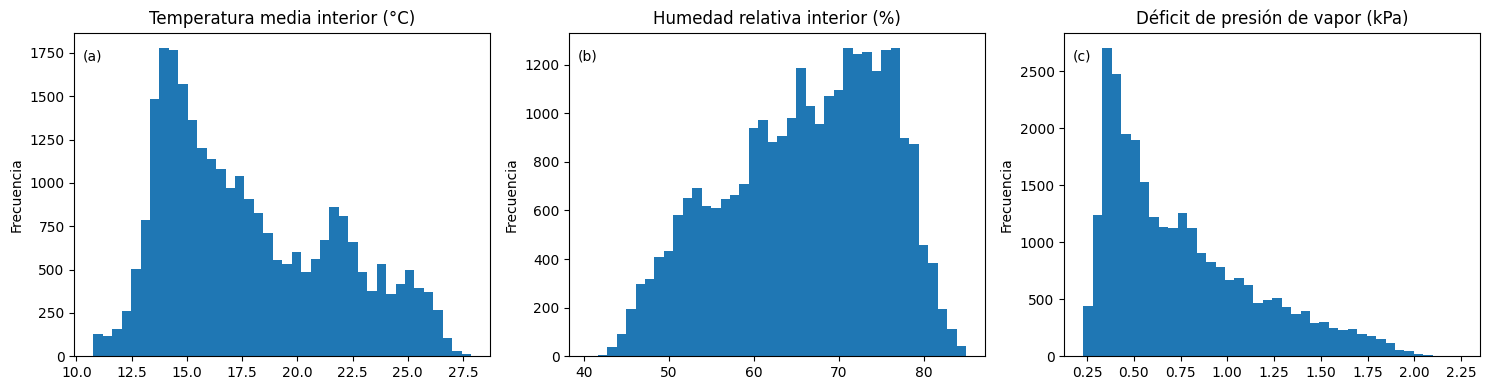

In [ ]:
# ============================================================
# 5) Calcular estadísticos descriptivos (Figura de tabla estadística)
# ============================================================
estadisticos = df_microclima[["T_prom_int", "RH", "VPD"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)
print("Estadísticos descriptivos (T_prom_int, RH, VPD):")
display(estadisticos)

# (Opcional) Exportar estadísticos
estadisticos.to_csv("estadisticos_descriptivos_microclima.csv", index=True)


# ============================================================
# 6) Graficar histogramas de T, RH y VPD (Figura de distribuciones)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

variables = ["T_prom_int", "RH", "VPD"]
titulos = [
    "Temperatura media interior (°C)",
    "Humedad relativa interior (%)",
    "Déficit de presión de vapor (kPa)"
]
letras = ["a", "b", "c"]

for ax, var, titulo, letra in zip(axes, variables, titulos, letras):
    ax.hist(df_microclima[var].dropna(), bins=40)
    ax.set_title(titulo)
    ax.set_ylabel("Frecuencia")
    ax.text(0.02, 0.95, f"({letra})", transform=ax.transAxes, ha="left", va="top")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 7) Definir umbrales y crear bandas fisiológicas
# ============================================================
def clasificar_T_fisio(T):
    if pd.isna(T):
        return np.nan
    if T < 18:
        return "T1_frio_<18"
    elif 18 <= T < 22:
        return "T2_fresco_18-22"
    elif 22 <= T <= 28:
        return "T3_optimo_22-28"
    elif 28 < T <= 32:
        return "T4_calido_28-32"
    else:
        return "T5_muy_calido_>32"

def clasificar_RH_fisio(RH):
    if pd.isna(RH):
        return np.nan
    if RH < 50:
        return "RH1_muy_seco_<50"
    elif 50 <= RH < 60:
        return "RH2_seco_50-60"
    elif 60 <= RH < 80:
        return "RH3_optimo_60-80"
    elif 80 <= RH < 90:
        return "RH4_humedo_80-90"
    else:
        return "RH5_muy_humedo_>90"

def clasificar_VPD_fisio(VPD):
    if pd.isna(VPD):
        return np.nan
    if VPD < 0.3:
        return "VPD1_muy_humedo_<0.3"
    elif 0.3 <= VPD < 0.4:
        return "VPD2_humedo_0.3-0.4"
    elif 0.4 <= VPD < 0.8:
        return "VPD3_optimo_0.4-0.8"
    elif 0.8 <= VPD < 1.0:
        return "VPD4_seco_0.8-1.0"
    else:
        return "VPD5_muy_seco_>1.0"

# Crear columnas de banda
df_microclima["banda_T_fisio"] = df_microclima["T_prom_int"].apply(clasificar_T_fisio)
df_microclima["banda_RH_fisio"] = df_microclima["RH"].apply(clasificar_RH_fisio)
df_microclima["banda_VPD_fisio"] = df_microclima["VPD"].apply(clasificar_VPD_fisio)


In [ ]:
# ============================================================
# 8) Resumir distribución de registros por bandas (n y porcentaje)
# ============================================================
def resumir_bandas(df_in, columna_banda):
    resumen = (
        df_in[columna_banda]
        .value_counts(dropna=False)
        .rename("n")
        .to_frame()
        .reset_index()
        .rename(columns={"index": columna_banda})
    )
    resumen["porcentaje"] = (resumen["n"] / resumen["n"].sum()) * 100
    return resumen

res_T = resumir_bandas(df_microclima, "banda_T_fisio")
res_RH = resumir_bandas(df_microclima, "banda_RH_fisio")
res_VPD = resumir_bandas(df_microclima, "banda_VPD_fisio")

print("Distribución por bandas T:")
display(res_T)
print("")

print("Distribución por bandas RH:")
display(res_RH)
print("")

print("Distribución por bandas VPD:")
display(res_VPD)

# Exportar tablas
res_T.to_csv("tabla_bandas_T.csv", index=False)
res_RH.to_csv("tabla_bandas_RH.csv", index=False)
res_VPD.to_csv("tabla_bandas_VPD.csv", index=False)

Distribución por bandas T:


,banda_T_fisio,n,porcentaje
0,T1_frio_<18,16147,58.947868
1,T2_fresco_18-22,6256,22.838785
2,T3_optimo_22-28,4989,18.213347



Distribución por bandas RH:


,banda_RH_fisio,n,porcentaje
0,RH3_optimo_60-80,18979,69.286653
1,RH2_seco_50-60,5879,21.462471
2,RH1_muy_seco_<50,1572,5.738902
3,RH4_humedo_80-90,962,3.511974



Distribución por bandas VPD:


,banda_VPD_fisio,n,porcentaje
0,VPD3_optimo_0.4-0.8,12326,44.998540
1,VPD5_muy_seco_>1.0,6621,24.171291
2,VPD2_humedo_0.3-0.4,4347,15.869597
3,VPD4_seco_0.8-1.0,3541,12.927132
4,VPD1_muy_humedo_<0.3,557,2.033440


In [ ]:
# ============================================================
# 9) Definir estado higrométrico del controlador
# ============================================================
def es_dia_por_fallback(fecha):
    # fallback 06:00–18:00, coherente con definición operativa
    h = fecha.hour
    return (h >= 6) and (h < 18)

df_microclima["esDia"] = df_microclima["fecha"].apply(es_dia_por_fallback)

def clasificar_estado_higro_ctrl(vpd, ah_gm3, esDia):
    if pd.isna(vpd) or pd.isna(ah_gm3) or pd.isna(esDia):
        return np.nan

    if bool(esDia):
        # Día
        if (vpd > 0.9) or (ah_gm3 < 11):
            return "SECO"
        if (vpd < 0.5) or (ah_gm3 > 16):
            return "HUMEDO"
        return "OPTIMO"
    else:
        # Noche
        if (vpd > 0.7) or (ah_gm3 < 9):
            return "SECO"
        if (vpd < 0.3) or (ah_gm3 > 14):
            return "HUMEDO"
        return "OPTIMO"

df_microclima["estado_higro_ctrl"] = df_microclima.apply(
    lambda r: clasificar_estado_higro_ctrl(r["VPD"], r["AH_gm3"], r["esDia"]),
    axis=1
)


In [ ]:
# ============================================================
# 10) Evaluar coherencia: bandas VPD vs estado higrométrico del controlador
# ============================================================
tabla_conteos = pd.crosstab(
    df_microclima["banda_VPD_fisio"],
    df_microclima["estado_higro_ctrl"],
    margins=True
)

tabla_prop_col = pd.crosstab(
    df_microclima["banda_VPD_fisio"],
    df_microclima["estado_higro_ctrl"],
    normalize="columns"
).round(3)

print("Tabla de contingencia (conteos) VPD vs estado_higro_ctrl:")
display(tabla_conteos)

print("Tabla de contingencia (proporciones por estado, normalize='columns'):")
display(tabla_prop_col)

# Exportar tablas
tabla_conteos.to_csv("tabla_VPD_vs_estado_conteos.csv")
tabla_prop_col.to_csv("tabla_VPD_vs_estado_proporciones.csv")


Tabla de contingencia (conteos) VPD vs estado_higro_ctrl:


estado_higro_ctrl,HUMEDO,OPTIMO,SECO,All
banda_VPD_fisio,,,,
VPD1_muy_humedo_<0.3,0,0,557,557
VPD2_humedo_0.3-0.4,0,125,4222,4347
VPD3_optimo_0.4-0.8,39,4668,7619,12326
VPD4_seco_0.8-1.0,0,346,3195,3541
VPD5_muy_seco_>1.0,0,0,6621,6621
All,39,5139,22214,27392


Tabla de contingencia (proporciones por estado, normalize='columns'):


estado_higro_ctrl,HUMEDO,OPTIMO,SECO
banda_VPD_fisio,,,
VPD1_muy_humedo_<0.3,0.0,0.000,0.025
VPD2_humedo_0.3-0.4,0.0,0.024,0.190
VPD3_optimo_0.4-0.8,1.0,0.908,0.343
VPD4_seco_0.8-1.0,0.0,0.067,0.144
VPD5_muy_seco_>1.0,0.0,0.000,0.298


In [ ]:
# ============================================================
# 11) Construir dataset supervisado multihorizonte (15/30/60 min)
#     Definir targets a futuro (t+h) para T_prom_int, RH y VPD
#     Construir predictores con retardos (lags) y variables actuales
#     Alinear X e Y y eliminar filas incompletas por bordes
# ============================================================

# ---------- Definir horizontes y variables objetivo ----------
horizontes_min = [15, 30, 60]
vars_obj = ["T_prom_int", "RH", "VPD"]

# ---------- Definir predictores base ----------
# Usar AH_gm3 como humedad absoluta en g/m³
vars_base = ["T_prom_int", "RH", "VPD", "AH_gm3", "DP", "delta_rocio"]
# Incluir actuadores como entradas exógenas
actuadores = [c for c in df_microclima.columns if c.startswith("A")]
if "HA10" in df_microclima.columns:
    actuadores.append("HA10")

# ---------- Preparar dataframe ordenado e indexado ----------
df_sup = (
    df_microclima
    .sort_values("fecha")
    .set_index("fecha")
    .copy()
)

# Eliminar columnas no utilizadas para evitar inconsistencias
for col in ["AH", "AH_calc"]:
    if col in df_sup.columns:
        df_sup = df_sup.drop(columns=[col])

# ---------- Crear variables de calendario ----------
df_sup["hora"] = df_sup.index.hour
df_sup["minuto"] = df_sup.index.minute
df_sup["dia_semana"] = df_sup.index.dayofweek

# ---------- Definir retardos y horizontes en pasos ----------
lags_min = [1, 5, 10, 15, 30, 60]
lags_pasos = sorted({int(np.round(lm / delta_min)) for lm in lags_min if int(np.round(lm / delta_min)) >= 1})

horizontes_pasos = {h: int(np.round(h / delta_min)) for h in horizontes_min}

print("delta_min (min):", delta_min)
print("lags_pasos:", lags_pasos)
print("horizontes_pasos:", horizontes_pasos)

# ---------- Generar variables con lags ----------
for lag in lags_pasos:
    for v in vars_base:
        if v in df_sup.columns:
            df_sup[f"{v}_lag{lag}"] = df_sup[v].shift(lag)

# ---------- Generar targets multihorizonte ----------
for h_min, h_pasos in horizontes_pasos.items():
    for v in vars_obj:
        df_sup[f"{v}_t+{h_min}"] = df_sup[v].shift(-h_pasos)

# ---------- Definir matriz X e Y ----------
cols_y = [f"{v}_t+{h}" for h in horizontes_min for v in vars_obj]

cols_lags = [c for c in df_sup.columns if "_lag" in c]
cols_x = vars_base + actuadores + ["hora", "minuto", "dia_semana"] + cols_lags

# Eliminar duplicados preservando orden
cols_x = list(dict.fromkeys(cols_x))
cols_y = list(dict.fromkeys(cols_y))

# Filtrar columnas inexistentes (evitar KeyError)
cols_x = [c for c in cols_x if c in df_sup.columns]
cols_y = [c for c in cols_y if c in df_sup.columns]

# Verificar integridad mínima
faltan_y = [c for c in [f"{v}_t+{h}" for h in horizontes_min for v in vars_obj] if c not in cols_y]
if len(faltan_y) > 0:
    raise ValueError(f"Faltan targets en df_sup: {faltan_y}")

# ---------- Construir dataset final y depurar NaN ----------
df_modelo = df_sup[cols_x + cols_y].dropna().copy()

print("Dataset supervisado (filas, columnas):", df_modelo.shape)
print("Número de variables X:", len(cols_x))
print("Número de variables Y:", len(cols_y))

display(df_modelo.head())

# ---------- Separar X e Y ----------
X = df_modelo[cols_x].copy()
Y = df_modelo[cols_y].copy()

print("X:", X.shape, "| Y:", Y.shape)

# ---------- Registrar columnas y exportar dataset supervisado ----------
cols_x_final = list(X.columns)
cols_y_final = list(Y.columns)

pd.Series(cols_x_final, name="cols_x").to_csv("cols_X_seccion11.csv", index=False)
pd.Series(cols_y_final, name="cols_y").to_csv("cols_Y_seccion11.csv", index=False)

X.to_csv("X_seccion11.csv", index=True)
Y.to_csv("Y_seccion11.csv", index=True)

print("Archivos generados:")
print(" - cols_X_seccion11.csv")
print(" - cols_Y_seccion11.csv")
print(" - X_seccion11.csv")
print(" - Y_seccion11.csv")



delta_min (min): 1.0
lags_pasos: [1, 5, 10, 15, 30, 60]
horizontes_pasos: {15: 15, 30: 30, 60: 60}
Dataset supervisado (filas, columnas): (27272, 67)
Número de variables X: 58
Número de variables Y: 9


,T_prom_int,RH,VPD,AH_gm3,DP,delta_rocio,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,HA10,hora,minuto,dia_semana,T_prom_int_lag1,RH_lag1,VPD_lag1,AH_gm3_lag1,DP_lag1,delta_rocio_lag1,T_prom_int_lag5,RH_lag5,VPD_lag5,AH_gm3_lag5,DP_lag5,delta_rocio_lag5,T_prom_int_lag10,RH_lag10,VPD_lag10,AH_gm3_lag10,DP_lag10,delta_rocio_lag10,T_prom_int_lag15,RH_lag15,VPD_lag15,AH_gm3_lag15,DP_lag15,delta_rocio_lag15,T_prom_int_lag30,RH_lag30,VPD_lag30,AH_gm3_lag30,DP_lag30,delta_rocio_lag30,T_prom_int_lag60,RH_lag60,VPD_lag60,AH_gm3_lag60,DP_lag60,delta_rocio_lag60,T_prom_int_t+15,RH_t+15,VPD_t+15,T_prom_int_t+30,RH_t+30,VPD_t+30,T_prom_int_t+60,RH_t+60,VPD_t+60
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-09-27 16:42:00,25.566667,54.70,1.48,13.00,15.78,9.786667,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16,42,5,25.733333,55.27,1.48,13.26,16.10,9.633333,25.500000,62.23,1.23,14.74,17.75,7.750000,25.166667,57.17,1.37,13.28,16.10,9.066667,25.166667,59.03,1.31,13.72,16.61,8.556667,23.644444,63.10,1.07,13.37,16.11,7.534444,22.200000,65.73,0.92,12.90,15.49,6.710000,25.800000,53.13,1.56,24.733333,54.10,1.43,24.000000,56.63,1.29
2025-09-27 16:43:00,25.533333,53.67,1.52,12.73,15.46,10.073333,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16,43,5,25.566667,54.70,1.48,13.00,15.78,9.786667,25.866667,59.87,1.34,14.47,17.48,8.386667,25.000000,56.30,1.38,12.96,15.71,9.290000,25.166667,56.27,1.40,13.08,15.85,9.316667,23.633333,60.73,1.15,12.94,15.61,8.023333,22.333333,65.77,0.92,13.01,15.62,6.713333,25.666667,50.93,1.62,24.800000,51.87,1.51,23.983333,56.03,1.31
2025-09-27 16:44:00,25.533333,51.57,1.58,12.23,14.84,10.693333,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16,44,5,25.533333,53.67,1.52,12.73,15.46,10.073333,25.833333,57.03,1.46,13.99,16.97,8.863333,25.000000,54.67,1.44,12.59,15.25,9.750000,25.200000,53.43,1.49,12.44,15.08,10.120000,23.966667,58.30,1.24,12.66,15.29,8.676667,22.700000,66.43,0.93,13.42,16.13,6.570000,25.566667,49.73,1.65,24.900000,52.10,1.51,23.966667,57.37,1.27
2025-09-27 16:45:00,25.500000,59.47,1.32,14.08,17.03,8.470000,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16,45,5,25.533333,51.57,1.58,12.23,14.84,10.693333,25.800000,51.23,1.67,12.62,15.35,10.450000,25.133333,54.37,1.45,12.59,15.26,9.873333,25.266667,51.23,1.57,11.97,14.49,10.776667,24.233333,56.43,1.32,12.44,15.03,9.203333,23.233333,64.20,1.02,13.37,16.10,7.133333,25.466667,58.17,1.36,24.933333,60.03,1.26,23.800000,59.13,1.20
2025-09-27 16:46:00,25.266667,56.97,1.39,13.31,16.14,9.126667,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16,46,5,25.500000,59.47,1.32,14.08,17.03,8.470000,25.733333,55.27,1.48,13.26,16.10,9.633333,25.266667,59.63,1.30,13.94,16.86,8.406667,25.300000,60.80,1.26,14.24,17.20,8.100000,24.566667,62.33,1.16,14.00,16.90,7.666667,23.633333,66.53,0.98,14.18,17.04,6.593333,25.300000,53.23,1.51,24.833333,57.47,1.33,23.500000,59.27,1.18


X: (27272, 58) | Y: (27272, 9)
Archivos generados:
 - cols_X_seccion11.csv
 - cols_Y_seccion11.csv
 - X_seccion11.csv
 - Y_seccion11.csv


In [ ]:
# ============================================================
# 12) Separar X e Y en train/val/test mediante índices temporales
#     Alinear conjuntos con el particionado de la Sección 4
#     Evitar fuga temporal mediante intersección por timestamp
# ============================================================

# Convertir a índice temporal para alinear por timestamp
X_idx = X.copy()
Y_idx = Y.copy()

# Definir índices por partición (desde Sección 4)
idx_train = pd.DatetimeIndex(df_train["fecha"])
idx_val   = pd.DatetimeIndex(df_val["fecha"])
idx_test  = pd.DatetimeIndex(df_test["fecha"])

# Intersectar con el índice disponible en X/Y (por bordes de lags/targets)
idx_train = idx_train.intersection(X_idx.index)
idx_val   = idx_val.intersection(X_idx.index)
idx_test  = idx_test.intersection(X_idx.index)

# Construir particiones finales
X_train, Y_train = X_idx.loc[idx_train].copy(), Y_idx.loc[idx_train].copy()
X_val,   Y_val   = X_idx.loc[idx_val].copy(),   Y_idx.loc[idx_val].copy()
X_test,  Y_test  = X_idx.loc[idx_test].copy(),  Y_idx.loc[idx_test].copy()

print("Tamaños finales:")
print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_val:  ", X_val.shape,   "| Y_val:  ", Y_val.shape)
print("X_test: ", X_test.shape,  "| Y_test: ", Y_test.shape)

# Exportar particiones
X_train.to_csv("X_train.csv", index=True)
Y_train.to_csv("Y_train.csv", index=True)
X_val.to_csv("X_val.csv", index=True)
Y_val.to_csv("Y_val.csv", index=True)
X_test.to_csv("X_test.csv", index=True)
Y_test.to_csv("Y_test.csv", index=True)

print("Archivos generados:")
print(" - X_train.csv, Y_train.csv")
print(" - X_val.csv,   Y_val.csv")
print(" - X_test.csv,  Y_test.csv")


Tamaños finales:
X_train: (19054, 58) | Y_train: (19054, 9)
X_val:   (3989, 58) | Y_val:   (3989, 9)
X_test:  (3989, 58) | Y_test:  (3989, 9)
Archivos generados:
 - X_train.csv, Y_train.csv
 - X_val.csv,   Y_val.csv
 - X_test.csv,  Y_test.csv


In [ ]:
# ---------- Instalar dependencias ----------
!pip -q install xgboost joblib


In [ ]:
# ============================================================
# 4.3.2) Configurar y entrenar modelo tabular XGBoost (baseline)
#     Cargar particiones X/Y (train/val/test)
#     Verificar consistencia temporal y dimensional
#     Entrenar un modelo por cada target (variable-horizonte)
#     Aplicar parada temprana con conjunto de validación
#     Evaluar MAE y RMSE en validación y prueba
#     Guardar modelos y tabla de métricas
# ============================================================


import os
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------- Definir rutas de entrada ----------
ruta_X_train = "X_train.csv"
ruta_Y_train = "Y_train.csv"
ruta_X_val   = "X_val.csv"
ruta_Y_val   = "Y_val.csv"
ruta_X_test  = "X_test.csv"
ruta_Y_test  = "Y_test.csv"

# ---------- Cargar particiones ----------
X_train = pd.read_csv(ruta_X_train, index_col=0)
Y_train = pd.read_csv(ruta_Y_train, index_col=0)

X_val = pd.read_csv(ruta_X_val, index_col=0)
Y_val = pd.read_csv(ruta_Y_val, index_col=0)

X_test = pd.read_csv(ruta_X_test, index_col=0)
Y_test = pd.read_csv(ruta_Y_test, index_col=0)

print("Tamaños cargados:")
print(f"X_train: {X_train.shape} | Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape} | Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test.shape} | Y_test:  {Y_test.shape}")

# ---------- Verificar NaN ----------
conteo_nan = {
    "X_train": int(X_train.isna().sum().sum()),
    "Y_train": int(Y_train.isna().sum().sum()),
    "X_val": int(X_val.isna().sum().sum()),
    "Y_val": int(Y_val.isna().sum().sum()),
    "X_test": int(X_test.isna().sum().sum()),
    "Y_test": int(Y_test.isna().sum().sum()),
}
print("Conteo total de NaN:", conteo_nan)

# ---------- Verificar consistencia de columnas ----------
if list(X_train.columns) != list(X_val.columns) or list(X_train.columns) != list(X_test.columns):
    raise ValueError("Las columnas de X no coinciden entre train/val/test.")
if list(Y_train.columns) != list(Y_val.columns) or list(Y_train.columns) != list(Y_test.columns):
    raise ValueError("Las columnas de Y no coinciden entre train/val/test.")

# ---------- Convertir índices a datetime si aplica ----------
def convertir_indice_datetime(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    try:
        df_out.index = pd.to_datetime(df_out.index)
    except Exception:
        pass
    return df_out

X_train = convertir_indice_datetime(X_train)
X_val   = convertir_indice_datetime(X_val)
X_test  = convertir_indice_datetime(X_test)

Y_train = convertir_indice_datetime(Y_train)
Y_val   = convertir_indice_datetime(Y_val)
Y_test  = convertir_indice_datetime(Y_test)

# ---------- Verificar separación temporal ----------
if np.issubdtype(X_train.index.dtype, np.datetime64):
    print("Rangos temporales:")
    print("Train:", X_train.index.min(), "->", X_train.index.max())
    print("Val:  ", X_val.index.min(),   "->", X_val.index.max())
    print("Test: ", X_test.index.min(),  "->", X_test.index.max())

# ---------- Definir función RMSE compatible ----------
def calcular_rmse(y_true, y_pred) -> float:
    """Calcular RMSE sin depender del argumento squared de sklearn."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ---------- Definir parámetros XGBoost ----------
params_xgb = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "seed": 42,
}
num_boost_round = 5000
early_stopping_rounds = 100
# ---------- Entrenar un modelo por cada target ----------
modelos = {}
metricas = []
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
nombres_features = X_train.columns.tolist()
for col_target in Y_train.columns:
    y_train = Y_train[col_target].values.astype(np.float32)
    y_val   = Y_val[col_target].values.astype(np.float32)
    y_test  = Y_test[col_target].values.astype(np.float32)
    dtrain = xgb.DMatrix(X_train_np, label=y_train, feature_names=nombres_features)
    dval   = xgb.DMatrix(X_val_np,   label=y_val,   feature_names=nombres_features)
    dtest  = xgb.DMatrix(X_test_np,  label=y_test,  feature_names=nombres_features)
    evals = [(dtrain, "train"), (dval, "val")]
    booster = xgb.train(
        params=params_xgb,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=False
    )
    # Predecir usando el mejor número de iteraciones
    it_fin = booster.best_iteration + 1
    yhat_val  = booster.predict(dval,  iteration_range=(0, it_fin))
    yhat_test = booster.predict(dtest, iteration_range=(0, it_fin))
    # Calcular métricas
    mae_val  = float(mean_absolute_error(y_val, yhat_val))
    rmse_val = calcular_rmse(y_val, yhat_val)
    mae_test  = float(mean_absolute_error(y_test, yhat_test))
    rmse_test = calcular_rmse(y_test, yhat_test)

    modelos[col_target] = booster
    metricas.append({
        "target": col_target,
        "best_iteration": int(booster.best_iteration),
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test,
    })

# ---------- Consolidar tabla de métricas ----------
df_metricas = pd.DataFrame(metricas).sort_values("target").reset_index(drop=True)
display(df_metricas)

print("Promedios (macro):")
print(df_metricas[["MAE_val","RMSE_val","MAE_test","RMSE_test"]].mean())

# ---------- Guardar resultados ----------
os.makedirs("modelos_xgb", exist_ok=True)

for target, booster in modelos.items():
    booster.save_model(os.path.join("modelos_xgb", f"xgb_{target}.json"))

df_metricas.to_csv("metricas_xgb_por_target.csv", index=False)

print("Archivos generados:")
print(" - modelos_xgb/xgb_<target>.json")
print(" - metricas_xgb_por_target.csv")


Tamaños cargados:
X_train: (19054, 58) | Y_train: (19054, 9)
X_val:   (3989, 58) | Y_val:   (3989, 9)
X_test:  (3989, 58) | Y_test:  (3989, 9)
Conteo total de NaN: {'X_train': 0, 'Y_train': 0, 'X_val': 0, 'Y_val': 0, 'X_test': 0, 'Y_test': 0}
Rangos temporales:
Train: 2025-09-27 16:42:00 -> 2025-10-13 11:35:00
Val:   2025-10-13 13:36:00 -> 2025-10-16 09:03:00
Test:  2025-10-16 11:04:00 -> 2025-10-19 06:27:00


,target,best_iteration,MAE_val,RMSE_val,MAE_test,RMSE_test
0,RH_t+15,119,1.689333,2.667219,1.127099,1.828429
1,RH_t+30,78,2.397442,3.393790,1.485003,2.299037
2,RH_t+60,53,3.284139,4.352235,2.094764,3.212762
3,T_prom_int_t+15,108,0.409698,0.649386,0.305787,0.530082
4,T_prom_int_t+30,125,0.612022,0.891838,0.416983,0.693735
5,T_prom_int_t+60,84,0.822281,1.173596,0.555329,0.885507
6,VPD_t+15,180,0.067502,0.115948,0.045825,0.082820
7,VPD_t+30,101,0.092054,0.149534,0.060405,0.107407
8,VPD_t+60,117,0.131015,0.193676,0.080141,0.137617


Promedios (macro):
MAE_val      1.056165
RMSE_val     1.509691
MAE_test     0.685704
RMSE_test    1.086377
dtype: float64
Archivos generados:
 - modelos_xgb/xgb_<target>.json
 - metricas_xgb_por_target.csv


In [ ]:
# ============================================================
# 4.3.3) Configurar y entrenar modelo secuencial LSTM
#     Definir variables de entrada y objetivos multihorizonte
#     Construir secuencias por partición (train/val/test)
#     Normalizar usando solo train
#     Entrenar red LSTM con early stopping
#     Evaluar métricas MAE y RMSE por target (val/test)
# ============================================================


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ---------- Definir parámetros de secuencias ----------
lookback_min = 60
horizontes_min = [15, 30, 60]
vars_obj = ["T_prom_int", "RH", "VPD"]

lookback_pasos = int(np.round(lookback_min / delta_min))
horizontes_pasos = {h: int(np.round(h / delta_min)) for h in horizontes_min}

print("delta_min (min):", delta_min)
print("lookback_pasos:", lookback_pasos)
print("horizontes_pasos:", horizontes_pasos)

# ---------- Definir variables de entrada ----------
vars_base = ["T_prom_int", "RH", "VPD", "AH_gm3", "DP", "delta_rocio"]

actuadores = [c for c in df_microclima.columns if c.startswith("A")]
if "HA10" in df_microclima.columns:
    actuadores.append("HA10")

# Definir variables de calendario (recomendación: codificación cíclica)
def agregar_calendario_ciclico(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    idx = pd.DatetimeIndex(df_out["fecha"])
    hora = idx.hour.values
    minuto = idx.minute.values
    dia_sem = idx.dayofweek.values

    # Calcular seno/coseno para hora y día de semana
    df_out["hora_sin"] = np.sin(2*np.pi*hora/24.0)
    df_out["hora_cos"] = np.cos(2*np.pi*hora/24.0)
    df_out["dia_sem_sin"] = np.sin(2*np.pi*dia_sem/7.0)
    df_out["dia_sem_cos"] = np.cos(2*np.pi*dia_sem/7.0)

    # Mantener minuto como cíclico (opcional)
    df_out["min_sin"] = np.sin(2*np.pi*minuto/60.0)
    df_out["min_cos"] = np.cos(2*np.pi*minuto/60.0)
    return df_out

df_micro_lstm = agregar_calendario_ciclico(df_microclima)

vars_cal = ["hora_sin", "hora_cos", "dia_sem_sin", "dia_sem_cos", "min_sin", "min_cos"]
vars_x = [v for v in (vars_base + actuadores + vars_cal) if v in df_micro_lstm.columns]

# ---------- Ordenar e indexar por tiempo ----------
df_micro_lstm = df_micro_lstm.sort_values("fecha").reset_index(drop=True)
df_micro_lstm["fecha"] = pd.to_datetime(df_micro_lstm["fecha"])
df_micro_lstm = df_micro_lstm.set_index("fecha")

# ---------- Definir función para construir secuencias por partición ----------
def construir_secuencias_multihorizonte(
    df_in: pd.DataFrame,
    vars_x: list,
    vars_obj: list,
    lookback_pasos: int,
    horizontes_pasos: dict
):
    """
    Construir X como secuencias (n, lookback, p) y Y como vector (n, 9):
      orden Y: [T_t+15, RH_t+15, VPD_t+15, T_t+30, RH_t+30, ...]
    """
    X_mat = df_in[vars_x].values.astype(np.float32)
    Y_base = df_in[vars_obj].values.astype(np.float32)

    max_h = max(horizontes_pasos.values())
    n_total = len(df_in)

    X_list, Y_list, t_list = [], [], []

    # Definir rangos válidos
    ini = lookback_pasos - 1
    fin = n_total - 1 - max_h

    for i in range(ini, fin + 1):
        x_seq = X_mat[i - lookback_pasos + 1 : i + 1, :]
        y_vec = []
        for h_min in sorted(horizontes_pasos.keys()):
            h = horizontes_pasos[h_min]
            y_fut = Y_base[i + h, :]
            y_vec.extend(list(y_fut))
        X_list.append(x_seq)
        Y_list.append(y_vec)
        t_list.append(df_in.index[i])

    X_out = np.stack(X_list, axis=0)
    Y_out = np.array(Y_list, dtype=np.float32)

    # Definir nombres de targets en el mismo orden
    cols_y = []
    for h_min in sorted(horizontes_pasos.keys()):
        for v in vars_obj:
            cols_y.append(f"{v}_t+{h_min}")

    return X_out, Y_out, cols_y, pd.DatetimeIndex(t_list)

# ---------- Construir splits por timestamp y generar secuencias ----------
idx_train = pd.DatetimeIndex(df_train["fecha"])
idx_val   = pd.DatetimeIndex(df_val["fecha"])
idx_test  = pd.DatetimeIndex(df_test["fecha"])

# Filtrar dataframes por partición (conservar continuidad interna)
df_train_lstm = df_micro_lstm.loc[df_micro_lstm.index.intersection(idx_train)].copy()
df_val_lstm   = df_micro_lstm.loc[df_micro_lstm.index.intersection(idx_val)].copy()
df_test_lstm  = df_micro_lstm.loc[df_micro_lstm.index.intersection(idx_test)].copy()

# Eliminar filas con NaN en variables requeridas
df_train_lstm = df_train_lstm.dropna(subset=vars_x + vars_obj).copy()
df_val_lstm   = df_val_lstm.dropna(subset=vars_x + vars_obj).copy()
df_test_lstm  = df_test_lstm.dropna(subset=vars_x + vars_obj).copy()

X_train_seq, Y_train_seq, cols_y, t_train = construir_secuencias_multihorizonte(
    df_train_lstm, vars_x, vars_obj, lookback_pasos, horizontes_pasos
)
X_val_seq, Y_val_seq, _, t_val = construir_secuencias_multihorizonte(
    df_val_lstm, vars_x, vars_obj, lookback_pasos, horizontes_pasos
)
X_test_seq, Y_test_seq, _, t_test = construir_secuencias_multihorizonte(
    df_test_lstm, vars_x, vars_obj, lookback_pasos, horizontes_pasos
)

print("Secuencias construidas:")
print("X_train_seq:", X_train_seq.shape, "| Y_train_seq:", Y_train_seq.shape)
print("X_val_seq:  ", X_val_seq.shape,   "| Y_val_seq:  ", Y_val_seq.shape)
print("X_test_seq: ", X_test_seq.shape,  "| Y_test_seq: ", Y_test_seq.shape)

# ---------- Normalizar X usando solo entrenamiento ----------
scaler = StandardScaler()

# Ajustar scaler sobre datos de train aplanados
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
scaler.fit(X_train_flat)

def transformar_secuencias(X_seq, scaler):
    X_flat = X_seq.reshape(-1, X_seq.shape[-1])
    X_scaled = scaler.transform(X_flat).reshape(X_seq.shape)
    return X_scaled.astype(np.float32)

X_train_seq = transformar_secuencias(X_train_seq, scaler)
X_val_seq   = transformar_secuencias(X_val_seq, scaler)
X_test_seq  = transformar_secuencias(X_test_seq, scaler)

# ---------- Definir arquitectura LSTM ----------
n_features = X_train_seq.shape[-1]
n_outputs  = Y_train_seq.shape[-1]
tf.random.set_seed(42)
np.random.seed(42)
modelo = models.Sequential([
    layers.Input(shape=(lookback_pasos, n_features)),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(n_outputs)
])
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae"
)
modelo.summary()
# ---------- Entrenar con early stopping ----------
cb_early = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
hist = modelo.fit(
    X_train_seq, Y_train_seq,
    validation_data=(X_val_seq, Y_val_seq),
    epochs=100,
    batch_size=256,
    callbacks=[cb_early],
    verbose=1
)

# ---------- Evaluar por target (val y test) ----------
def calcular_rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

Yhat_val  = modelo.predict(X_val_seq, verbose=0)
Yhat_test = modelo.predict(X_test_seq, verbose=0)

metricas = []
for j, target in enumerate(cols_y):
    y_val  = Y_val_seq[:, j]
    y_test = Y_test_seq[:, j]

    yhat_val  = Yhat_val[:, j]
    yhat_test = Yhat_test[:, j]

    mae_val  = float(mean_absolute_error(y_val, yhat_val))
    rmse_val = calcular_rmse(y_val, yhat_val)

    mae_test  = float(mean_absolute_error(y_test, yhat_test))
    rmse_test = calcular_rmse(y_test, yhat_test)

    metricas.append({
        "target": target,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test
    })

df_metricas_lstm = pd.DataFrame(metricas).sort_values("target").reset_index(drop=True)
display(df_metricas_lstm)

print("Promedios (macro):")
print(df_metricas_lstm[["MAE_val","RMSE_val","MAE_test","RMSE_test"]].mean())

# ---------- Guardar resultados ----------
import os
os.makedirs("resultados_lstm", exist_ok=True)

df_metricas_lstm.to_csv("resultados_lstm/metricas_lstm_por_target.csv", index=False)
modelo.save("resultados_lstm/modelo_lstm.keras")

print("Archivos generados:")
print(" - resultados_lstm/metricas_lstm_por_target.csv")
print(" - resultados_lstm/modelo_lstm.keras")


delta_min (min): 1.0
lookback_pasos: 60
horizontes_pasos: {15: 15, 30: 30, 60: 60}
Secuencias construidas:
X_train_seq: (18995, 60, 28) | Y_train_seq: (18995, 9)
X_val_seq:   (3870, 60, 28) | Y_val_seq:   (3870, 9)
X_test_seq:  (3930, 60, 28) | Y_test_seq:  (3930, 9)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,553 (111.54 KB)

 Trainable params: 28,553 (111.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 26.5433 - val_loss: 15.6071
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 11.0571 - val_loss: 4.5253
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0512 - val_loss: 4.3259
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6244 - val_loss: 3.8935
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.1687 - val_loss: 2.7216
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4278 - val_loss: 1.9528
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0811 - val_loss: 1.7479
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.9607 - val_loss: 1.6240
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9015 - val_loss: 1.4958
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.8829 - val_loss: 1.5088
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.7923 - val_loss: 1.5553
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - lo

,target,MAE_val,RMSE_val,MAE_test,RMSE_test
0,RH_t+15,1.754303,2.672736,1.425687,1.923269
1,RH_t+30,2.131810,3.080330,1.493573,2.158273
2,RH_t+60,2.942027,3.947802,1.988903,2.843359
3,T_prom_int_t+15,0.502005,0.785953,0.475529,0.715410
4,T_prom_int_t+30,0.614783,0.912872,0.514148,0.811268
5,T_prom_int_t+60,0.882310,1.287033,0.734650,1.147107
6,VPD_t+15,0.076438,0.130305,0.063206,0.104086
7,VPD_t+30,0.089171,0.146084,0.068449,0.121476
8,VPD_t+60,0.116597,0.183081,0.092939,0.160455


Promedios (macro):
MAE_val      1.012161
RMSE_val     1.460688
MAE_test     0.761898
RMSE_test    1.109412
dtype: float64
Archivos generados:
 - resultados_lstm/metricas_lstm_por_target.csv
 - resultados_lstm/modelo_lstm.keras


In [ ]:
df_metricas_lstm = pd.DataFrame(metricas).sort_values("target").reset_index(drop=True)
display(df_metricas_lstm)

print("Promedios (macro):")
print(df_metricas_lstm[["MAE_val","RMSE_val","MAE_test","RMSE_test"]].mean())


,target,MAE_val,RMSE_val,MAE_test,RMSE_test
0,RH_t+15,1.754303,2.672736,1.425687,1.923269
1,RH_t+30,2.131810,3.080330,1.493573,2.158273
2,RH_t+60,2.942027,3.947802,1.988903,2.843359
3,T_prom_int_t+15,0.502005,0.785953,0.475529,0.715410
4,T_prom_int_t+30,0.614783,0.912872,0.514148,0.811268
5,T_prom_int_t+60,0.882310,1.287033,0.734650,1.147107
6,VPD_t+15,0.076438,0.130305,0.063206,0.104086
7,VPD_t+30,0.089171,0.146084,0.068449,0.121476
8,VPD_t+60,0.116597,0.183081,0.092939,0.160455


Promedios (macro):
MAE_val      1.012161
RMSE_val     1.460688
MAE_test     0.761898
RMSE_test    1.109412
dtype: float64


Métricas XGBoost cargadas desde: metricas_xgb_por_target.csv
Métricas LSTM cargadas desde: resultados_lstm/metricas_lstm_por_target.csv

Resumen macro:


,promedio_macro
MAE_val_xgb,1.056165
RMSE_val_xgb,1.509691
MAE_test_xgb,0.685704
RMSE_test_xgb,1.086377
MAE_val_lstm,1.012161
RMSE_val_lstm,1.460688
MAE_test_lstm,0.761898
RMSE_test_lstm,1.109412



Resumen por variable y horizonte (test):


,variable,h_min,MAE_test_xgb,RMSE_test_xgb,MAE_test_lstm,RMSE_test_lstm,delta_MAE_test,delta_RMSE_test
0,RH,15,1.127099,1.828429,1.425687,1.923269,0.298589,0.094841
1,RH,30,1.485003,2.299037,1.493573,2.158273,0.008570,-0.140763
2,RH,60,2.094764,3.212762,1.988903,2.843359,-0.105861,-0.369403
3,T_prom_int,15,0.305787,0.530082,0.475529,0.715410,0.169743,0.185327
4,T_prom_int,30,0.416983,0.693735,0.514148,0.811268,0.097164,0.117533
5,T_prom_int,60,0.555329,0.885507,0.734650,1.147107,0.179322,0.261600
6,VPD,15,0.045825,0.082820,0.063206,0.104086,0.017382,0.021266
7,VPD,30,0.060405,0.107407,0.068449,0.121476,0.008044,0.014069
8,VPD,60,0.080141,0.137617,0.092939,0.160455,0.012798,0.022838


Nulos tras coerción numérica en Y_train (solo targets): 0
Score global normalizado (promedio sobre targets):
NRMSE_test_xgb     0.253009
NRMSE_test_lstm    0.282270
NMAE_test_xgb      0.152760
NMAE_test_lstm     0.180059
dtype: float64

Score global normalizado (promedio sobre targets):
NRMSE_test_xgb     0.253009
NRMSE_test_lstm    0.282270
NMAE_test_xgb      0.152760
NMAE_test_lstm     0.180059
dtype: float64

Archivos generados:
 - comparacion_xgb_vs_lstm_por_target.csv
 - comparacion_resumen_por_variable_horizonte.csv


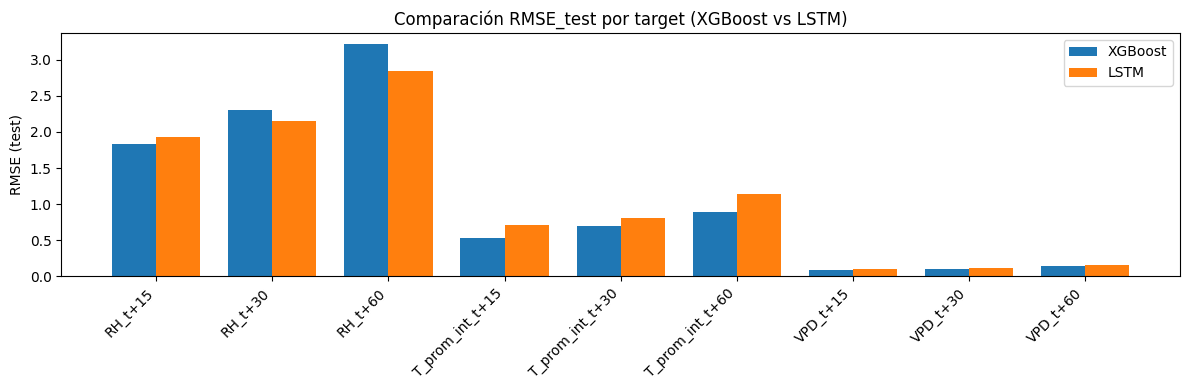

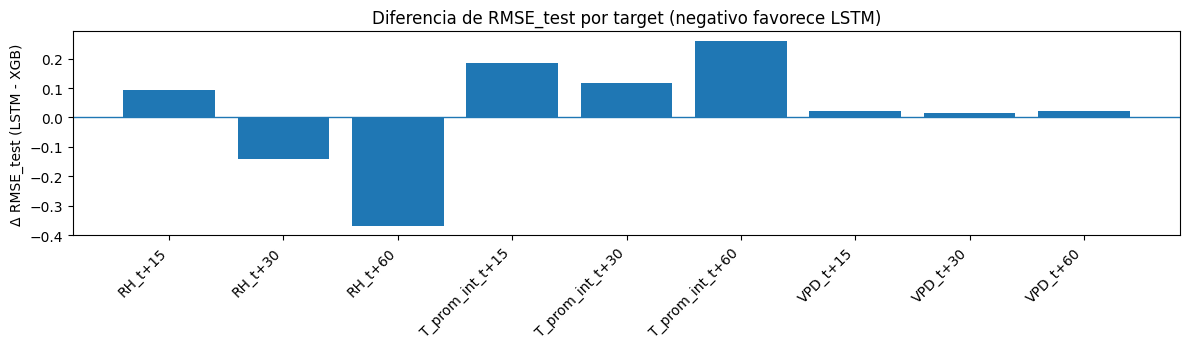

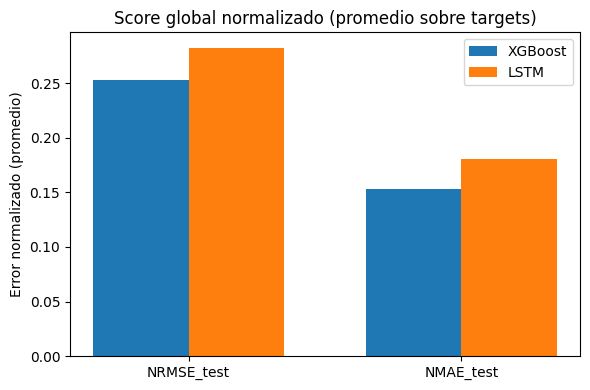

In [ ]:
# ============================================================
# 4.3.4) Comparar desempeño y definir criterio de selección
#     - Cargar métricas por target (XGBoost vs LSTM)
#     - Unificar tabla comparativa por MAE/RMSE (val y test)
#     - Resúmenes macro y por variable/horizonte (test)
#     - Score global normalizado (NRMSE/NMAE) usando sigma_train
#     - Gráficas comparativas (RMSE/MAE y normalizadas)
# ============================================================


import matplotlib.pyplot as plt

# ---------- Utilidad: cargar CSV con fallback ----------
def cargar_csv_fallback(rutas):
    for r in rutas:
        if os.path.exists(r):
            return pd.read_csv(r), r
    raise FileNotFoundError(f"No se encontró ninguno de los archivos: {rutas}")

# ---------- 1) Cargar métricas ----------
mx, ruta_mx = cargar_csv_fallback([
    "metricas_xgb_por_target.csv",
    "metricas_xgboost_multihorizonte.csv"
])

ml, ruta_ml = cargar_csv_fallback([
    "resultados_lstm/metricas_lstm_por_target.csv",
    "metricas_lstm_por_target.csv"
])

print("Métricas XGBoost cargadas desde:", ruta_mx)
print("Métricas LSTM cargadas desde:", ruta_ml)

# ---------- 2) Mantener solo columnas necesarias ----------
cols_base = ["target", "MAE_val", "RMSE_val", "MAE_test", "RMSE_test"]
mx = mx[[c for c in cols_base if c in mx.columns]].copy()
ml = ml[[c for c in cols_base if c in ml.columns]].copy()

# Renombrar para comparar
mx = mx.rename(columns={
    "MAE_val": "MAE_val_xgb", "RMSE_val": "RMSE_val_xgb",
    "MAE_test": "MAE_test_xgb", "RMSE_test": "RMSE_test_xgb"
})
ml = ml.rename(columns={
    "MAE_val": "MAE_val_lstm", "RMSE_val": "RMSE_val_lstm",
    "MAE_test": "MAE_test_lstm", "RMSE_test": "RMSE_test_lstm"
})

# ---------- 3) Unir por target ----------
dfc = mx.merge(ml, on="target", how="inner")

# Chequeo mínimo
if dfc.empty:
    raise ValueError("La unión por 'target' quedó vacía. Verificar nombres de targets en ambos CSV.")

# ---------- 4) Extraer variable y horizonte desde el nombre del target ----------
def extraer_var_h(target: str):
    partes = str(target).split("_t+")
    var = partes[0]
    h = int(partes[1]) if len(partes) > 1 else np.nan
    return var, h

dfc[["variable", "h_min"]] = dfc["target"].apply(lambda s: pd.Series(extraer_var_h(s)))

# ---------- 5) Diferencias (LSTM - XGB) ----------
for met in ["MAE_val", "RMSE_val", "MAE_test", "RMSE_test"]:
    dfc[f"delta_{met}"] = dfc[f"{met}_lstm"] - dfc[f"{met}_xgb"]

# ---------- 6) Resumen macro ----------
macro = dfc[[
    "MAE_val_xgb","RMSE_val_xgb","MAE_test_xgb","RMSE_test_xgb",
    "MAE_val_lstm","RMSE_val_lstm","MAE_test_lstm","RMSE_test_lstm"
]].mean().to_frame("promedio_macro")

print("\nResumen macro:")
display(macro)

# ---------- 7) Resumen por variable y horizonte (test) ----------
res_var_h = dfc.groupby(["variable","h_min"], as_index=False)[
    ["MAE_test_xgb","RMSE_test_xgb","MAE_test_lstm","RMSE_test_lstm",
     "delta_MAE_test","delta_RMSE_test"]
].mean().sort_values(["variable","h_min"]).reset_index(drop=True)

print("\nResumen por variable y horizonte (test):")
display(res_var_h)

# ---------- 8) Score normalizado (NRMSE/NMAE) ----------
# ---------- Calcular score normalizado (evitar dominancia por escala) ----------
# Requerir cargar Y_train para estimar sigma por target (solo columnas numéricas)

Y_train_raw = pd.read_csv("Y_train.csv")

# 1) Identificar y retirar columnas típicas de tiempo/índice
cols_drop = []
for c in ["fecha", "datetime", "time", "timestamp"]:
    if c in Y_train_raw.columns:
        cols_drop.append(c)

# columna índice exportada por pandas (muy común)
for c in ["Unnamed: 0", "index"]:
    if c in Y_train_raw.columns:
        cols_drop.append(c)

Y_train_raw = Y_train_raw.drop(columns=cols_drop, errors="ignore")

# 2) Mantener solo columnas que correspondan a targets comparados
targets = dfc["target"].unique().tolist()
cols_targets = [c for c in targets if c in Y_train_raw.columns]

if len(cols_targets) == 0:
    raise ValueError(
        "No se encontró ninguna columna target en Y_train.csv que coincida con dfc['target']. "
        "Verificar nombres de columnas en Y_train.csv y nombres en los CSV de métricas."
    )

# 3) Convertir a numérico (por si vienen como object)
Y_train_num = Y_train_raw[cols_targets].apply(pd.to_numeric, errors="coerce")

# Diagnóstico mínimo (opcional)
n_nan = int(Y_train_num.isna().sum().sum())
print("Nulos tras coerción numérica en Y_train (solo targets):", n_nan)

# 4) Calcular sigma por target (evitar sigma=0)
sigma = Y_train_num.std(axis=0).replace(0, np.nan)

# 5) Mapear sigma a la tabla comparativa
dfc["sigma_train"] = dfc["target"].map(sigma.to_dict())

# 6) Calcular métricas normalizadas en test
dfc["NRMSE_test_xgb"]  = dfc["RMSE_test_xgb"]  / dfc["sigma_train"]
dfc["NRMSE_test_lstm"] = dfc["RMSE_test_lstm"] / dfc["sigma_train"]

dfc["NMAE_test_xgb"]   = dfc["MAE_test_xgb"]   / dfc["sigma_train"]
dfc["NMAE_test_lstm"]  = dfc["MAE_test_lstm"]  / dfc["sigma_train"]

# 7) Score global normalizado (promedio sobre targets válidos)
score_norm = dfc[["NRMSE_test_xgb","NRMSE_test_lstm","NMAE_test_xgb","NMAE_test_lstm"]].mean()

print("Score global normalizado (promedio sobre targets):")
print(score_norm)

score_norm = dfc[["NRMSE_test_xgb","NRMSE_test_lstm","NMAE_test_xgb","NMAE_test_lstm"]].mean()

print("\nScore global normalizado (promedio sobre targets):")
print(score_norm)

# ---------- 9) Guardar salidas ----------
dfc.to_csv("comparacion_xgb_vs_lstm_por_target.csv", index=False)
res_var_h.to_csv("comparacion_resumen_por_variable_horizonte.csv", index=False)

print("\nArchivos generados:")
print(" - comparacion_xgb_vs_lstm_por_target.csv")
print(" - comparacion_resumen_por_variable_horizonte.csv")

# ============================================================
# 10) Gráficas comparativas (regresión: MAE/RMSE; no accuracy)
# ============================================================

# --- (A) RMSE_test por target: barras agrupadas ---
df_plot = dfc.sort_values(["variable","h_min"]).copy()
x = np.arange(len(df_plot))
w = 0.38

plt.figure(figsize=(12,4))
plt.bar(x - w/2, df_plot["RMSE_test_xgb"].values, width=w, label="XGBoost")
plt.bar(x + w/2, df_plot["RMSE_test_lstm"].values, width=w, label="LSTM")
plt.xticks(x, df_plot["target"].values, rotation=45, ha="right")
plt.ylabel("RMSE (test)")
plt.title("Comparación RMSE_test por target (XGBoost vs LSTM)")
plt.legend()
plt.tight_layout()
plt.show()

# --- (B) Delta RMSE_test (LSTM - XGB): valores < 0 favorecen LSTM ---
plt.figure(figsize=(12,3.6))
plt.bar(x, df_plot["delta_RMSE_test"].values)
plt.axhline(0, linewidth=1)
plt.xticks(x, df_plot["target"].values, rotation=45, ha="right")
plt.ylabel("Δ RMSE_test (LSTM - XGB)")
plt.title("Diferencia de RMSE_test por target (negativo favorece LSTM)")
plt.tight_layout()
plt.show()

# --- (C) Score global normalizado: NRMSE y NMAE (promedios) ---
labels = ["NRMSE_test", "NMAE_test"]
x2 = np.arange(len(labels))
w2 = 0.35

vals_xgb  = [score_norm["NRMSE_test_xgb"],  score_norm["NMAE_test_xgb"]]
vals_lstm = [score_norm["NRMSE_test_lstm"], score_norm["NMAE_test_lstm"]]

plt.figure(figsize=(6,4))
plt.bar(x2 - w2/2, vals_xgb,  width=w2, label="XGBoost")
plt.bar(x2 + w2/2, vals_lstm, width=w2, label="LSTM")
plt.xticks(x2, labels)
plt.ylabel("Error normalizado (promedio)")
plt.title("Score global normalizado (promedio sobre targets)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 4.4) Agente predictivo + Supervisor E_Ctrl (CORREGIDO)
#     - Incluye IEx (A5–A10), A12 ECO+veto, A11, HA10
#     - Basado en "Lógica de control Ctrl (actualizado)"
# ============================================================

import os
from dataclasses import dataclass
from typing import Dict, Optional, Tuple
import xgboost as xgb


# ============================================================
# Helpers psicrométricos (fallbacks si faltan columnas)
# ============================================================

def _es_nan(x) -> bool:
    try:
        return pd.isna(x)
    except Exception:
        return True

def presion_saturacion_kpa(T_c: float) -> float:
    # Tetens (kPa)
    return float(0.6108 * np.exp((17.27 * T_c) / (T_c + 237.3)))

def calcular_vpd_kpa(T_c: float, RH_pct: float) -> float:
    if _es_nan(T_c) or _es_nan(RH_pct):
        return np.nan
    es = presion_saturacion_kpa(float(T_c))
    ea = es * (float(RH_pct) / 100.0)
    return float(max(es - ea, 0.0))

def calcular_dp_c(T_c: float, RH_pct: float) -> float:
    if _es_nan(T_c) or _es_nan(RH_pct):
        return np.nan
    RH = float(RH_pct)
    if RH <= 0:
        return np.nan
    a, b = 17.27, 237.3
    alpha = (a * float(T_c)) / (b + float(T_c)) + np.log(RH / 100.0)
    return float((b * alpha) / (a - alpha))

def calcular_AH_gm3(T_c: float, RH_pct: float) -> float:
    """
    Humedad absoluta (g/m3) a partir de T y RH.
    ρv = 216.7 * (e_hPa / T_K)
    """
    if _es_nan(T_c) or _es_nan(RH_pct):
        return np.nan
    es_kpa = presion_saturacion_kpa(float(T_c))
    e_kpa = es_kpa * (float(RH_pct) / 100.0)
    e_hpa = e_kpa * 10.0
    T_k = float(T_c) + 273.15
    return float(216.7 * (e_hpa / T_k))

def asegurar_variables_operativas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Asegura (si es posible) columnas operativas usadas por el supervisor:
    - T_prom_int, RH, VPD, AH_gm3, DP, delta_rocio
    """
    out = df.copy()
    if "fecha" in out.columns:
        out["fecha"] = pd.to_datetime(out["fecha"])

    # T_prom_int
    if "T_prom_int" not in out.columns:
        if all(c in out.columns for c in ["T2", "T3", "T4"]):
            out["T_prom_int"] = out[["T2", "T3", "T4"]].mean(axis=1)
        elif "T" in out.columns:
            out["T_prom_int"] = out["T"]
        else:
            out["T_prom_int"] = np.nan

    # RH
    if "RH" not in out.columns:
        if all(c in out.columns for c in ["H2", "H3", "H4"]):
            out["RH"] = out[["H2", "H3", "H4"]].mean(axis=1)
        elif "H" in out.columns:
            out["RH"] = out["H"]
        else:
            out["RH"] = np.nan

    # DP
    if "DP" not in out.columns:
        out["DP"] = out.apply(lambda r: calcular_dp_c(r["T_prom_int"], r["RH"]), axis=1)

    # VPD
    if "VPD" not in out.columns:
        out["VPD"] = out.apply(lambda r: calcular_vpd_kpa(r["T_prom_int"], r["RH"]), axis=1)

    # AH_gm3
    if "AH_gm3" not in out.columns:
        if "AH" in out.columns:
            out["AH_gm3"] = out["AH"]
        else:
            out["AH_gm3"] = out.apply(lambda r: calcular_AH_gm3(r["T_prom_int"], r["RH"]), axis=1)

    # delta_rocio = T - DP
    if "delta_rocio" not in out.columns:
        out["delta_rocio"] = out["T_prom_int"] - out["DP"]

    return out


# ============================================================
# 4.4.1) Integración del modelo predictivo en inferencia (XGBoost)
# ============================================================

# --- (A) Cargar lista de features EXACTA usada en entrenamiento ---
X_train_ref = pd.read_csv("X_train.csv", index_col=0)
features_xgb = X_train_ref.columns.tolist()

# --- (B) Cargar modelos XGBoost por target ---
def cargar_modelos_xgb(ruta_modelos="modelos_xgb"):
    modelos = {}
    for fname in os.listdir(ruta_modelos):
        if fname.endswith(".json") and fname.startswith("xgb_"):
            target = fname.replace("xgb_", "").replace(".json", "")
            booster = xgb.Booster()
            booster.load_model(os.path.join(ruta_modelos, fname))
            modelos[target] = booster
    if len(modelos) == 0:
        raise FileNotFoundError("No se encontraron modelos .json en la carpeta 'modelos_xgb'.")
    return modelos

modelos_xgb = cargar_modelos_xgb("modelos_xgb")

def construir_features_tabulares(df_micro: pd.DataFrame,
                                 fecha_t: pd.Timestamp,
                                 features_objetivo: list):
    """
    Reconstruye un vector de features (1 x p) compatible con XGBoost,
    usando df_microclima ya depurado/sincronizado y con variables operativas.
    """
    df = asegurar_variables_operativas(df_micro)
    df = df.sort_values("fecha").set_index("fecha")

    if fecha_t not in df.index:
        df = df.loc[df.index <= fecha_t]
        if df.empty:
            raise ValueError("No hay datos <= fecha_t para construir features.")
        fecha_t = df.index.max()

    def add_calendario(dfi):
        out = dfi.copy()
        idx = out.index
        out["hora"] = idx.hour
        out["minuto"] = idx.minute
        out["dia_semana"] = idx.dayofweek
        return out

    df_feat = add_calendario(df)

    # Detectar lags requeridos desde names tipo *_lagK
    lags_req = []
    for col in features_objetivo:
        if "_lag" in col:
            try:
                k = int(col.split("_lag")[-1])
                lags_req.append(k)
            except Exception:
                pass
    lags_req = sorted(set(lags_req))

    columnas_base_para_lag = ["T_prom_int", "RH", "VPD", "AH_gm3", "DP", "delta_rocio"]
    for k in lags_req:
        for v in columnas_base_para_lag:
            if v in df_feat.columns and f"{v}_lag{k}" not in df_feat.columns:
                df_feat[f"{v}_lag{k}"] = df_feat[v].shift(k)

    fila = df_feat.loc[[fecha_t]].copy()

    for col in features_objetivo:
        if col not in fila.columns:
            fila[col] = np.nan

    X_t = fila[features_objetivo].copy()

    n_nan = int(X_t.isna().sum().sum())
    if n_nan > 0:
        raise ValueError(
            f"Features incompletas en t={fecha_t}. NaN totales: {n_nan}. "
            f"Revisa lags/ventana de historia o faltantes en df_microclima."
        )

    return X_t, fecha_t

def predecir_multihorizonte_xgb(modelos: dict, X_t: pd.DataFrame):
    dmat = xgb.DMatrix(X_t.values.astype(np.float32), feature_names=X_t.columns.tolist())
    preds = {target: float(booster.predict(dmat)[0]) for target, booster in modelos.items()}
    return preds


# ============================================================
# 4.4.2) Supervisor de actuación compatible con E_Ctrl (CORREGIDO)
# ============================================================

def es_dia_fallback(fecha: pd.Timestamp) -> bool:
    h = int(fecha.hour)
    return (h >= 6) and (h < 18)

def clasificar_estado_higro_ctrl(vpd, ah_gm3, esDia):
    if pd.isna(vpd) or pd.isna(ah_gm3) or pd.isna(esDia):
        return np.nan
    if bool(esDia):
        if (vpd > 0.9) or (ah_gm3 < 11):
            return "SECO"
        if (vpd < 0.5) or (ah_gm3 > 16):
            return "HUMEDO"
        return "OPTIMO"
    else:
        if (vpd > 0.7) or (ah_gm3 < 9):
            return "SECO"
        if (vpd < 0.3) or (ah_gm3 > 14):
            return "HUMEDO"
        return "OPTIMO"

def calcular_step_termico(T_prom: float) -> int:
    if pd.isna(T_prom):
        return -1
    if T_prom < 22.0:
        return -1
    step = int(np.floor(T_prom) - 22)
    return int(min(max(step, 0), 8))

def plan_rex_por_step(step: int) -> Dict[str, Dict[str, float]]:
    plan = {f"A{i}": {"duty": 0.0, "on_min": 0.0, "off_min": 0.0} for i in range(1, 5)}
    if step < 0:
        return plan

    def set_actuadores(act_list, on_min, off_min):
        duty = 1.0 if off_min == 0 else float(on_min / (on_min + off_min))
        for a in act_list:
            plan[a] = {"duty": duty, "on_min": float(on_min), "off_min": float(off_min)}

    if step == 0:
        set_actuadores(["A1"], 2, 10)
    elif step == 1:
        set_actuadores(["A1", "A2"], 5, 10)
    elif step == 2:
        set_actuadores(["A1", "A2", "A3"], 10, 10)
    elif step == 3:
        set_actuadores(["A1", "A2", "A3", "A4"], 15, 5)
    elif step == 4:
        set_actuadores(["A1", "A2", "A3", "A4"], 30, 5)
    elif step == 5:
        set_actuadores(["A1", "A2", "A3", "A4"], 45, 5)
    else:
        set_actuadores(["A1", "A2", "A3", "A4"], 1, 0)  # continuo

    return plan

def estimar_deltaT_pared(medidas: Dict) -> float:
    Ts = []
    for c in ["T2", "T3", "T4", "T5"]:
        if c in medidas and not pd.isna(medidas[c]):
            Ts.append(float(medidas[c]))
    if len(Ts) < 2:
        return np.nan
    T_top = float(np.nanmax(Ts))

    base = []
    for c in ["T2", "T3", "T4"]:
        if c in medidas and not pd.isna(medidas[c]):
            base.append(float(medidas[c]))
    if len(base) == 0:
        return np.nan
    T_med = float(np.nanmean(base))
    return float(T_top - T_med)

def nivel_iex_deseado(step: int, deltaT: float) -> int:
    if step < 0:
        return 0
    if step <= 3:
        return 0

    if pd.isna(deltaT):
        if step in [4, 5]:
            return 0
        if step == 6:
            return 1
        if step >= 7:
            return 2

    dT = float(deltaT)

    if step in [4, 5]:
        if dT >= 3.5:
            return 2
        if dT >= 2.0:
            return 1
        return 0

    if step == 6:
        if dT >= 4.5:
            return 3
        if dT >= 3.5:
            return 2
        return 1

    if step == 7:
        if dT >= 3.5:
            return 3
        return 2

    if dT >= 3.0:
        return 3
    return 2

def plan_iex_por_nivel(nivel: int) -> Dict[str, float]:
    plan = {f"A{i}": 0.0 for i in range(5, 11)}
    if nivel <= 0:
        return plan
    if nivel == 1:
        plan["A5"] = 1.0
        plan["A6"] = 1.0
        return plan
    if nivel == 2:
        for a in ["A5", "A6", "A7", "A8"]:
            plan[a] = 1.0
        return plan
    for i in range(5, 11):
        plan[f"A{i}"] = 1.0
    return plan

def plan_a12_por_step(step: int) -> Dict[str, float]:
    if step < 1:
        return {"duty": 0.0, "on_min": 0.0, "off_min": 0.0}
    if step in [1, 2]:
        return {"duty": 0.0, "on_min": 0.0, "off_min": 0.0}
    if step == 3:
        on_min, off_min = 5.0, 15.0
        return {"duty": on_min / (on_min + off_min), "on_min": on_min, "off_min": off_min}
    if step == 4:
        on_min, off_min = 10.0, 20.0
        return {"duty": on_min / (on_min + off_min), "on_min": on_min, "off_min": off_min}
    if step == 5:
        on_min, off_min = 15.0, 15.0
        return {"duty": on_min / (on_min + off_min), "on_min": on_min, "off_min": off_min}
    return {"duty": 1.0, "on_min": 1.0, "off_min": 0.0}

def clasificar_exterior_por_delta_AH(delta_AH: float) -> str:
    if pd.isna(delta_AH):
        return "NA"
    if delta_AH >= 2.0:
        return "MAS_SECO"
    if delta_AH <= -2.0:
        return "MAS_HUMEDO"
    return "SIMILAR"

def plan_a11(modo: str, esDia: bool) -> Dict[str, float]:
    if modo == "HUM_EXT":
        on_s, periodo_s = (30.0, 300.0) if esDia else (60.0, 600.0)
        return {"duty": on_s / periodo_s, "on_s": on_s, "periodo_s": periodo_s}
    if modo == "SECADO":
        on_s, periodo_s = (180.0, 600.0) if esDia else (300.0, 900.0)
        return {"duty": on_s / periodo_s, "on_s": on_s, "periodo_s": periodo_s}
    return {"duty": 0.0, "on_s": 0.0, "periodo_s": 0.0}

def plan_ha10(esDia: bool) -> Dict[str, float]:
    on_s, periodo_s = (20.0, 480.0) if esDia else (40.0, 720.0)
    return {"duty": on_s / periodo_s, "on_s": on_s, "periodo_s": periodo_s}


# ============================================================
# Estado del supervisor (persistencias + veto A12)
# ============================================================

@dataclass
class EstadoSupervisor:
    step_prev: Optional[int] = None
    nivel_iex_prev: int = 0
    a12_veto_hasta: Optional[pd.Timestamp] = None

    cand_subir_nivel: Optional[int] = None
    cand_subir_desde: Optional[pd.Timestamp] = None
    cand_bajar_nivel: Optional[int] = None
    cand_bajar_desde: Optional[pd.Timestamp] = None


class SupervisorECtrl:
    def __init__(self,
                 persist_subir_min: float = 5.0,
                 persist_bajar_min: float = 10.0,
                 veto_a12_min: float = 6.0):
        self.persist_subir = pd.Timedelta(minutes=persist_subir_min)
        self.persist_bajar = pd.Timedelta(minutes=persist_bajar_min)
        self.veto_a12 = pd.Timedelta(minutes=veto_a12_min)
        self.estado = EstadoSupervisor()

    def _actualizar_nivel_iex(self, fecha_t: pd.Timestamp, deseado: int, step: int) -> int:
        if step < 0:
            self.estado.cand_subir_nivel = None
            self.estado.cand_subir_desde = None
            self.estado.cand_bajar_nivel = None
            self.estado.cand_bajar_desde = None
            self.estado.nivel_iex_prev = 0
            return 0

        actual = int(self.estado.nivel_iex_prev)

        if deseado == actual:
            self.estado.cand_subir_nivel = None
            self.estado.cand_subir_desde = None
            self.estado.cand_bajar_nivel = None
            self.estado.cand_bajar_desde = None
            return actual

        if deseado > actual:
            if self.estado.cand_subir_nivel != deseado:
                self.estado.cand_subir_nivel = deseado
                self.estado.cand_subir_desde = fecha_t
            if (fecha_t - self.estado.cand_subir_desde) >= self.persist_subir:
                actual = deseado
                self.estado.nivel_iex_prev = actual
                self.estado.cand_subir_nivel = None
                self.estado.cand_subir_desde = None
            return actual

        # deseado < actual
        if self.estado.cand_bajar_nivel != deseado:
            self.estado.cand_bajar_nivel = deseado
            self.estado.cand_bajar_desde = fecha_t
        if (fecha_t - self.estado.cand_bajar_desde) >= self.persist_bajar:
            actual = deseado
            self.estado.nivel_iex_prev = actual
            self.estado.cand_bajar_nivel = None
            self.estado.cand_bajar_desde = None
        return actual

    def recomendar(self, medidas: Dict, pred_15: Dict, fecha_t: pd.Timestamp) -> Dict:
        esDia = es_dia_fallback(fecha_t)

        def _tomar_pred(claves, default):
            for k in claves:
                if (k in pred_15) and (not pd.isna(pred_15[k])):
                    return float(pred_15[k])
            return default

        T_act = float(medidas.get("T_prom_int", np.nan))
        VPD_act = float(medidas.get("VPD", np.nan))

        T_use = _tomar_pred(["T_prom_int_t+15", "T_t+15", "T_prom_t+15"], T_act)
        VPD_use = _tomar_pred(["VPD_t+15"], VPD_act)

        AH_int = float(medidas.get("AH_gm3", np.nan))
        delta_rocio = float(medidas.get("delta_rocio", np.nan))

        step = calcular_step_termico(T_use)

        if step < 0:
            return {
                "esDia": bool(esDia),
                "step_termico": step,
                "estado_higro_pred": "NA",
                "motivo_seguridad": "T_PROM_MENOR_22",
                **{f"A{i}_duty": 0.0 for i in range(1, 5)},
                **{f"A{i}_duty": 0.0 for i in range(5, 11)},
                "IEx_nivel": 0,
                "A12_duty": 0.0, "A12_on_min": 0.0, "A12_off_min": 0.0,
                "A11_mode": "OFF", "A11_duty": 0.0, "A11_on_s": 0.0, "A11_periodo_s": 0.0,
                "HA10_mode": "OFF", "HA10_duty": 0.0, "HA10_on_s": 0.0, "HA10_periodo_s": 0.0,
            }

        estado_higro = clasificar_estado_higro_ctrl(VPD_use, AH_int, esDia)

        bloqueo_cond = (not pd.isna(delta_rocio)) and (delta_rocio <= 2.0)
        precaucion_humedad = (not pd.isna(delta_rocio)) and (
            (esDia and delta_rocio <= 4.0) or ((not esDia) and delta_rocio <= 3.0)
        )

        # --- REx TOP (A1–A4) ---
        rex = plan_rex_por_step(step)
        duty_rex = {a: rex[a]["duty"] for a in rex.keys()}

        # --- IEx PARED (A5–A10) ---
        deltaT = medidas.get("deltaT_pared", np.nan)
        if pd.isna(deltaT):
            deltaT = estimar_deltaT_pared(medidas)

        nivel_deseado = nivel_iex_deseado(step, float(deltaT) if not pd.isna(deltaT) else np.nan)

        nivel_prev_antes = int(self.estado.nivel_iex_prev)
        nivel_actual = self._actualizar_nivel_iex(fecha_t, nivel_deseado, step)
        iex = plan_iex_por_nivel(nivel_actual)

        # --- Veto A12 ---
        escalada_pared = nivel_actual > nivel_prev_antes
        escalada_top = (self.estado.step_prev is not None) and (step > self.estado.step_prev)

        if escalada_top or escalada_pared:
            nuevo_veto = fecha_t + self.veto_a12
            if self.estado.a12_veto_hasta is None:
                self.estado.a12_veto_hasta = nuevo_veto
            else:
                self.estado.a12_veto_hasta = max(self.estado.a12_veto_hasta, nuevo_veto)

        # actualizar step_prev luego de evaluar escalada_top
        self.estado.step_prev = step

        # --- A12 ECO por step + veto ---
        a12 = plan_a12_por_step(step)
        if step < 6:
            if (self.estado.a12_veto_hasta is not None) and (fecha_t < self.estado.a12_veto_hasta):
                a12 = {"duty": 0.0, "on_min": 0.0, "off_min": 0.0}

        # --- Exterior: AH_ext (para ΔAH y A11/HA10) ---
        AH_ext = medidas.get("AH_ext_gm3", np.nan)
        if pd.isna(AH_ext) and ("HE" in medidas) and (not pd.isna(medidas["HE"])):
            AH_ext = float(medidas["HE"])

        if pd.isna(AH_ext):
            T_ext = medidas.get("T1", np.nan)
            RH_ext = medidas.get("H1", np.nan)
            if pd.isna(T_ext) or pd.isna(RH_ext):
                T_ext = medidas.get("T_OWM", T_ext)
                RH_ext = medidas.get("RH_OWM", RH_ext)
            if (not pd.isna(T_ext)) and (not pd.isna(RH_ext)):
                AH_ext = calcular_AH_gm3(float(T_ext), float(RH_ext))

        delta_AH = np.nan
        if (not pd.isna(AH_int)) and (not pd.isna(AH_ext)):
            delta_AH = float(AH_int - AH_ext)

        ext_rel = clasificar_exterior_por_delta_AH(delta_AH)

        # --- A11 ---
        a11_mode = "OFF"
        a11_plan = {"duty": 0.0, "on_s": 0.0, "periodo_s": 0.0}

        if bloqueo_cond:
            a11_mode = "OFF_BLOQUEO_ROCIO"
        else:
            if (estado_higro == "SECO" and ext_rel == "MAS_HUMEDO"
                and (not precaucion_humedad) and (not pd.isna(delta_rocio)) and (delta_rocio >= 6.0)):
                a11_mode = "HUM_EXT"
                a11_plan = plan_a11(a11_mode, esDia)
            elif (estado_higro in ["OPTIMO", "HUMEDO"] and ext_rel == "MAS_SECO"
                  and ((pd.isna(delta_rocio)) or (delta_rocio >= 3.0))):
                a11_mode = "SECADO"
                a11_plan = plan_a11(a11_mode, esDia)

        # --- HA10 ---
        ha10_mode = "OFF"
        ha10_plan = {"duty": 0.0, "on_s": 0.0, "periodo_s": 0.0}

        if bloqueo_cond:
            ha10_mode = "OFF_BLOQUEO_ROCIO"
        else:
            cond_T = (not pd.isna(T_use)) and (T_use > 24.0)
            cond_seco = (estado_higro == "SECO")
            cond_rocio = (not pd.isna(delta_rocio)) and (delta_rocio >= 6.0)
            cond_no_a11_hum = (a11_mode != "HUM_EXT")
            cond_ext_no_seco = (ext_rel != "MAS_SECO") or (ext_rel == "NA")

            if precaucion_humedad:
                cond_rocio = False

            if cond_T and cond_seco and cond_rocio and cond_no_a11_hum and cond_ext_no_seco:
                ha10_mode = "PULSO"
                ha10_plan = plan_ha10(esDia)

        # coherencias
        if a11_mode == "HUM_EXT":
            ha10_mode = "OFF_POR_A11_HUM_EXT"
            ha10_plan = {"duty": 0.0, "on_s": 0.0, "periodo_s": 0.0}

        if ha10_plan["duty"] > 0.0:
            a11_mode = "OFF_POR_HA10"
            a11_plan = {"duty": 0.0, "on_s": 0.0, "periodo_s": 0.0}

        rec = {
            "esDia": bool(esDia),
            "step_termico": int(step),
            "deltaT_pared": float(deltaT) if not pd.isna(deltaT) else np.nan,
            "IEx_nivel": int(nivel_actual),
            "estado_higro_pred": estado_higro,

            "delta_rocio": float(delta_rocio) if not pd.isna(delta_rocio) else np.nan,
            "AH_int_gm3": float(AH_int) if not pd.isna(AH_int) else np.nan,
            "AH_ext_gm3": float(AH_ext) if not pd.isna(AH_ext) else np.nan,
            "delta_AH": float(delta_AH) if not pd.isna(delta_AH) else np.nan,
            "ext_rel": ext_rel,

            **{f"{a}_duty": float(duty_rex[a]) for a in duty_rex.keys()},
            **{f"{a}_duty": float(iex[a]) for a in iex.keys()},

            "A12_duty": float(a12["duty"]),
            "A12_on_min": float(a12["on_min"]),
            "A12_off_min": float(a12["off_min"]),
            "A12_veto_hasta": self.estado.a12_veto_hasta,

            "A11_mode": a11_mode,
            "A11_duty": float(a11_plan["duty"]),
            "A11_on_s": float(a11_plan["on_s"]),
            "A11_periodo_s": float(a11_plan["periodo_s"]),

            "HA10_mode": ha10_mode,
            "HA10_duty": float(ha10_plan["duty"]),
            "HA10_on_s": float(ha10_plan["on_s"]),
            "HA10_periodo_s": float(ha10_plan["periodo_s"]),
        }
        return rec


# ============================================================
# 4.4.3) Ejecución demo + registro
# ============================================================

def extraer_medidas_actuales(df_micro: pd.DataFrame, fecha_t: pd.Timestamp) -> Tuple[Dict, pd.Timestamp]:
    df = asegurar_variables_operativas(df_micro)
    df = df.sort_values("fecha").set_index("fecha")

    if fecha_t not in df.index:
        df = df.loc[df.index <= fecha_t]
        if df.empty:
            raise ValueError("No hay datos <= fecha_t para extraer medidas.")
        fecha_t = df.index.max()

    fila = df.loc[fecha_t]

    medidas = {
        "T_prom_int": float(fila.get("T_prom_int", np.nan)),
        "RH": float(fila.get("RH", np.nan)),
        "VPD": float(fila.get("VPD", np.nan)),
        "AH_gm3": float(fila.get("AH_gm3", np.nan)),
        "DP": float(fila.get("DP", np.nan)),
        "delta_rocio": float(fila.get("delta_rocio", np.nan)),
    }

    for c in ["T1", "H1", "T2", "T3", "T4", "T5", "T_OWM", "RH_OWM", "HE"]:
        if c in fila.index:
            medidas[c] = float(fila.get(c, np.nan))

    return medidas, fecha_t

def registrar_recomendacion(ruta_csv, fecha_t, medidas, pred, rec):
    fila = {"fecha": fecha_t}
    for k, v in medidas.items():
        fila[f"med_{k}"] = v
    for k, v in pred.items():
        fila[f"pred_{k}"] = v
    for k, v in rec.items():
        fila[f"rec_{k}"] = str(v) if isinstance(v, pd.Timestamp) else v

    df_out = pd.DataFrame([fila])
    if os.path.exists(ruta_csv):
        df_out.to_csv(ruta_csv, mode="a", header=False, index=False)
    else:
        df_out.to_csv(ruta_csv, index=False)


# ---------------- DEMO: último timestamp disponible ----------------

fecha_demo = pd.to_datetime(df_microclima["fecha"]).max()

X_t, fecha_t_ok = construir_features_tabulares(df_microclima, fecha_demo, features_xgb)
preds = predecir_multihorizonte_xgb(modelos_xgb, X_t)
pred_15 = {k: v for k, v in preds.items() if k.endswith("_t+15")}

medidas, fecha_t_ok = extraer_medidas_actuales(df_microclima, fecha_t_ok)

supervisor = SupervisorECtrl(persist_subir_min=5.0, persist_bajar_min=10.0, veto_a12_min=6.0)
rec = supervisor.recomendar(medidas, pred_15, fecha_t_ok)

os.makedirs("resultados_supervisor", exist_ok=True)
ruta_log = "resultados_supervisor/log_recomendaciones.csv"
registrar_recomendacion(ruta_log, fecha_t_ok, medidas, pred_15, rec)

print("Fecha:", fecha_t_ok)
print("Pred (+15):", pred_15)
print("Recomendaciones:", rec)
print("Log guardado en:", ruta_log)




Fecha: 2025-10-19 07:27:00
Pred (+15): {'T_prom_int_t+15': 13.946516990661621, 'VPD_t+15': 0.3887786269187927, 'RH_t+15': 75.03474426269531}
Recomendaciones: {'esDia': True, 'step_termico': -1, 'estado_higro_pred': 'NA', 'motivo_seguridad': 'T_PROM_MENOR_22', 'A1_duty': 0.0, 'A2_duty': 0.0, 'A3_duty': 0.0, 'A4_duty': 0.0, 'A5_duty': 0.0, 'A6_duty': 0.0, 'A7_duty': 0.0, 'A8_duty': 0.0, 'A9_duty': 0.0, 'A10_duty': 0.0, 'IEx_nivel': 0, 'A12_duty': 0.0, 'A12_on_min': 0.0, 'A12_off_min': 0.0, 'A11_mode': 'OFF', 'A11_duty': 0.0, 'A11_on_s': 0.0, 'A11_periodo_s': 0.0, 'HA10_mode': 'OFF', 'HA10_duty': 0.0, 'HA10_on_s': 0.0, 'HA10_periodo_s': 0.0}
Log guardado en: resultados_supervisor/log_recomendaciones.csv


In [ ]:
# ============================================================
# 4.5) Fase 5: Evaluación mediante simulación histórica y pruebas en sombra
#      - Replay histórico (offline) + “shadow testing” (sin actuar)
#      - Métricas predicción vs GT (t+15) y análisis de recomendaciones
#      - Resúmenes globales, por escenarios y acuerdo con actuadores históricos
# ============================================================

import os

from typing import Dict, List, Optional, Tuple
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# Utilidades
# ============================================================

def _max_lag_en_features(features: List[str]) -> int:
    max_lag = 0
    for c in features:
        if "_lag" in c:
            try:
                k = int(c.split("_lag")[-1])
                max_lag = max(max_lag, k)
            except Exception:
                pass
    return int(max_lag)

def _estimar_dt_median_seg(idx: pd.DatetimeIndex) -> float:
    if len(idx) < 3:
        return 300.0  # fallback 5 min
    dt = idx.to_series().diff().dropna().dt.total_seconds().values
    dt = dt[np.isfinite(dt)]
    if len(dt) == 0:
        return 300.0
    return float(np.median(dt))

def _alinear_valor_futuro_forward(df_idx: pd.DataFrame,
                                  fecha_t: pd.Timestamp,
                                  horizonte_min: int,
                                  col: str,
                                  tolerancia_seg: int) -> float:
    """
    Ground-truth a futuro usando el primer timestamp >= (t + horizonte),
    aceptando si cae dentro de tolerancia.
    """
    if col not in df_idx.columns:
        return np.nan

    t_obj = fecha_t + pd.Timedelta(minutes=horizonte_min)
    idx = df_idx.index
    pos = idx.searchsorted(t_obj, side="left")
    if pos >= len(idx):
        return np.nan

    t_real = idx[pos]
    if (t_real - t_obj) > pd.Timedelta(seconds=int(tolerancia_seg)):
        return np.nan

    return float(df_idx.iloc[pos][col])

def seleccionar_tiempos_por_stride(df_idx: pd.DataFrame,
                                  salto_min: int,
                                  horizonte_eval_min: int,
                                  max_lag: int) -> List[pd.Timestamp]:
    """
    Selecciona instantes reales del índice, con stride aproximado a salto_min,
    garantizando:
      - suficiente historia para lags
      - suficiente futuro para GT a horizonte_eval_min
    """
    idx = df_idx.index
    if len(idx) < 10:
        return []

    dt_med = _estimar_dt_median_seg(idx)
    h_steps = int(np.ceil((horizonte_eval_min * 60) / dt_med))
    stride = int(max(1, round((salto_min * 60) / dt_med)))

    pos_ini = max_lag + 1
    pos_fin = len(idx) - h_steps - 1
    if pos_fin <= pos_ini:
        return []

    return list(idx[pos_ini:pos_fin:stride])

def _metricas_safe(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """
    Calcula MAE/RMSE/R2 si hay suficientes pares válidos; si no, devuelve NaN.
    """
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 3:
        return {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}
    yt = y_true[mask]
    yp = y_pred[mask]
    return {
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "R2": float(r2_score(yt, yp))
    }

def _conmutaciones_onoff(serie_duty: pd.Series, umbral_on: float = 0.0) -> int:
    """
    Conmutaciones entre OFF/ON según duty>umbral_on
    """
    onoff = (serie_duty.fillna(0.0) > umbral_on).astype(int)
    if len(onoff) < 2:
        return 0
    return int((onoff.diff().abs().fillna(0) > 0).sum())

def _extraer_actuadores_historicos(df_idx: pd.DataFrame,
                                  fecha_t: pd.Timestamp,
                                  actuadores: List[str]) -> Dict[str, float]:
    out = {}
    fila = df_idx.loc[fecha_t]
    for a in actuadores:
        if a in df_idx.columns:
            out[a] = float(fila.get(a, np.nan))
        else:
            out[a] = np.nan
    return out


# ============================================================
# Fase 5: Replay histórico + pruebas en sombra
# ============================================================

def ejecutar_fase5_replay_sombra(df_microclima: pd.DataFrame,
                                features_xgb: List[str],
                                modelos_xgb: Dict,
                                supervisor,  # instancia SupervisorECtrl
                                salto_min: int = 5,
                                horizonte_inferencia_min: int = 15,
                                horizonte_eval_min: int = 15,
                                tolerancia_futuro_seg: int = 1800,  # 30 min por robustez
                                max_muestras: int = 5000,
                                carpeta_salida: str = "resultados_fase5") -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Ejecuta:
      - replay “shadow” (sin actuar) recorriendo el histórico
      - genera archivo de replay, y resúmenes (global, por escenarios, acuerdo actuadores)

    Requisitos:
      - df_microclima con columna 'fecha'
      - funciones construir_features_tabulares(...) y predecir_multihorizonte_xgb(...)
        ya definidas en tu notebook (las de la Fase 4.4)
      - supervisor = SupervisorECtrl(...)
    """

    # --- Preparación dataset indexado ---
    df = df_microclima.copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.sort_values("fecha")

    # Asegurar variables operativas (usa tu función de Fase 4)
    df = asegurar_variables_operativas(df)
    df_idx = df.set_index("fecha").sort_index()

    # --- Selección de instantes válidos ---
    max_lag = _max_lag_en_features(features_xgb)
    tiempos = seleccionar_tiempos_por_stride(df_idx, salto_min, horizonte_eval_min, max_lag)
    tiempos = tiempos[:max_muestras]

    if len(tiempos) == 0:
        raise ValueError(
            "No hay instantes válidos para replay. Causas típicas: "
            "df_microclima muy corto, max_lag alto, o falta futuro para horizonte_eval."
        )

    # --- Loop replay ---
    filas = []
    actuadores_interes_hist = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10","A11","A12","HA10"]

    for t in tiempos:
        # 1) medidas actuales (desde df_idx)
        fila = df_idx.loc[t]

        medidas = {
            "T_prom_int": float(fila.get("T_prom_int", np.nan)),
            "RH": float(fila.get("RH", np.nan)),
            "VPD": float(fila.get("VPD", np.nan)),
            "AH_gm3": float(fila.get("AH_gm3", np.nan)),
            "DP": float(fila.get("DP", np.nan)),
            "delta_rocio": float(fila.get("delta_rocio", np.nan)),
        }
        # sensores auxiliares si existen
        for c in ["T1","H1","T2","T3","T4","T5","T_OWM","RH_OWM","HE","AH_ext_gm3","deltaT_pared"]:
            if c in df_idx.columns:
                medidas[c] = float(fila.get(c, np.nan))
        # 2) construir X(t) y predecir
        try:
            X_t, t_ok = construir_features_tabulares(df, t, features_xgb)
            preds = predecir_multihorizonte_xgb(modelos_xgb, X_t)
        except Exception:
            # si falla por features incompletas, saltar ese instante
            continue
        # 3) filtrar horizonte requerido para supervisor
        suf = f"_t+{int(horizonte_inferencia_min)}"
        pred_h = {k: float(v) for k, v in preds.items() if k.endswith(suf)}
        # 4) supervisor (recomendación)
        rec = supervisor.recomendar(medidas, pred_h, t_ok)

        # 5) guardas (para análisis), recalculadas de forma explícita
        esDia = bool(rec.get("esDia", False))
        delta_rocio = float(medidas.get("delta_rocio", np.nan))
        bloqueo_cond = (np.isfinite(delta_rocio) and (delta_rocio <= 2.0))
        precaucion_humedad = (np.isfinite(delta_rocio) and (
            (esDia and delta_rocio <= 4.0) or ((not esDia) and delta_rocio <= 3.0)
        ))

        # 6) GT a futuro (t + horizonte_eval_min) para variables objetivo
        gt_T = _alinear_valor_futuro_forward(df_idx, t_ok, horizonte_eval_min, "T_prom_int", tolerancia_futuro_seg)
        gt_RH = _alinear_valor_futuro_forward(df_idx, t_ok, horizonte_eval_min, "RH", tolerancia_futuro_seg)
        gt_VPD = _alinear_valor_futuro_forward(df_idx, t_ok, horizonte_eval_min, "VPD", tolerancia_futuro_seg)

        # 7) predicciones a evaluar (intentamos mapear nombres típicos)
        #    OJO: en tus modelos los targets suelen ser: T_prom_int_t+15, RH_t+15, VPD_t+15
        pred_T = np.nan
        pred_RH = np.nan
        pred_VPD = np.nan
        for k, v in pred_h.items():
            if k.startswith("T_prom_int"):
                pred_T = float(v)
            elif k.startswith("RH"):
                pred_RH = float(v)
            elif k.startswith("VPD"):
                pred_VPD = float(v)

        # 8) actuadores históricos (si existen)
        hist = _extraer_actuadores_historicos(df_idx, t_ok, actuadores_interes_hist)

        # 9) consolidar fila
        out = {"fecha": t_ok}

        # medidas
        for k, v in medidas.items():
            out[f"med_{k}"] = v

        # prediccion usada por supervisor
        for k, v in pred_h.items():
            out[f"pred_{k}"] = v

        # recomendaciones
        for k, v in rec.items():
            out[f"rec_{k}"] = str(v) if isinstance(v, pd.Timestamp) else v

        # guardas/flags
        out["flag_bloqueo_cond"] = int(bloqueo_cond)
        out["flag_precaucion_humedad"] = int(precaucion_humedad)

        # GT y pred para métricas
        out["gt_T_prom_int_t+15"] = gt_T
        out["gt_RH_t+15"] = gt_RH
        out["gt_VPD_t+15"] = gt_VPD

        out["pred_T_prom_int_t+15"] = pred_T
        out["pred_RH_t+15"] = pred_RH
        out["pred_VPD_t+15"] = pred_VPD

        # históricos actuadores
        for a, val in hist.items():
            out[f"hist_{a}"] = val

        filas.append(out)

    if len(filas) == 0:
        raise ValueError("Replay terminó sin filas. Revisa lags/features o tolerancias de GT.")

    df_replay = pd.DataFrame(filas).sort_values("fecha").reset_index(drop=True)

    # ============================================================
    # Resumen global
    # ============================================================

    # Métricas de predicción (t+15)
    mT = _metricas_safe(df_replay["gt_T_prom_int_t+15"].values, df_replay["pred_T_prom_int_t+15"].values)
    mRH = _metricas_safe(df_replay["gt_RH_t+15"].values, df_replay["pred_RH_t+15"].values)
    mVPD = _metricas_safe(df_replay["gt_VPD_t+15"].values, df_replay["pred_VPD_t+15"].values)

    # Violación de coherencia (no debería ocurrir)
    viol_ha10_a11 = 0
    if "rec_HA10_mode" in df_replay.columns and "rec_A11_mode" in df_replay.columns:
        viol_ha10_a11 = int(((df_replay["rec_HA10_mode"].astype(str).str.contains("PULSO")) &
                             (df_replay["rec_A11_mode"].astype(str).str.contains("HUM_EXT"))).sum())

    resumen_global = {
        "n_filas": int(len(df_replay)),
        "n_bloqueo_cond": int(df_replay["flag_bloqueo_cond"].sum()),
        "n_precaucion_humedad": int(df_replay["flag_precaucion_humedad"].sum()),
        "violacion_HA10_con_A11_HUM_EXT": int(viol_ha10_a11),

        "T_prom_int_MAE": mT["MAE"], "T_prom_int_RMSE": mT["RMSE"], "T_prom_int_R2": mT["R2"],
        "RH_MAE": mRH["MAE"], "RH_RMSE": mRH["RMSE"], "RH_R2": mRH["R2"],
        "VPD_MAE": mVPD["MAE"], "VPD_RMSE": mVPD["RMSE"], "VPD_R2": mVPD["R2"],
    }

    # Duty promedio y conmutaciones recomendadas (A1..A12, A11, HA10 si existen)
    for a in ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10","A11","A12","HA10"]:
        col = f"rec_{a}_duty" if a != "HA10" else "rec_HA10_duty"
        if col in df_replay.columns:
            resumen_global[f"duty_prom_{a}"] = float(pd.to_numeric(df_replay[col], errors="coerce").fillna(0.0).mean())
            resumen_global[f"conmut_{a}"] = _conmutaciones_onoff(pd.to_numeric(df_replay[col], errors="coerce"))

    df_resumen_global = pd.DataFrame([resumen_global]).T

    # ============================================================
    # Resumen por escenarios (esDia, step_termico, estado_higro_pred)
    # ============================================================

    # Columnas rec_* pueden no existir en algunas filas por rutas de seguridad; normalizamos
    for c in ["rec_esDia", "rec_step_termico", "rec_estado_higro_pred"]:
        if c not in df_replay.columns:
            df_replay[c] = np.nan

    df_replay["esc_esDia"] = df_replay["rec_esDia"].astype(bool, errors="ignore")
    df_replay["esc_step_termico"] = pd.to_numeric(df_replay["rec_step_termico"], errors="coerce").fillna(-999).astype(int)
    df_replay["esc_estado_higro"] = df_replay["rec_estado_higro_pred"].astype(str)

    # duty relevantes
    for col in ["rec_A12_duty", "rec_A11_duty", "rec_HA10_duty"]:
        if col not in df_replay.columns:
            df_replay[col] = 0.0
    df_replay["rec_A12_duty"] = pd.to_numeric(df_replay["rec_A12_duty"], errors="coerce").fillna(0.0)
    df_replay["rec_A11_duty"] = pd.to_numeric(df_replay["rec_A11_duty"], errors="coerce").fillna(0.0)
    df_replay["rec_HA10_duty"] = pd.to_numeric(df_replay["rec_HA10_duty"], errors="coerce").fillna(0.0)

    df_resumen_esc = (
        df_replay
        .groupby(["esc_esDia", "esc_step_termico", "esc_estado_higro"], dropna=False)
        .agg(
            n=("fecha", "count"),
            esc_bloqueo_cond=("flag_bloqueo_cond", "sum"),
            esc_precaucion_humedad=("flag_precaucion_humedad", "sum"),
            rec_A12_duty=("rec_A12_duty", "mean"),
            rec_A11_duty=("rec_A11_duty", "mean"),
            rec_HA10_duty=("rec_HA10_duty", "mean"),
        )
        .reset_index()
        .sort_values(["esc_esDia", "esc_step_termico", "esc_estado_higro"])
        .reset_index(drop=True)
    )

    # ============================================================
    # Acuerdo actuadores (histórico ON/OFF vs recomendado ON/OFF)
    # ============================================================

    filas_acuerdo = []
    for a in ["A11","A12"]:  # enfocado en los más relevantes (puedes ampliar)
        col_hist = f"hist_{a}"
        col_rec = f"rec_{a}_duty"
        if (col_hist in df_replay.columns) and (col_rec in df_replay.columns):
            h = pd.to_numeric(df_replay[col_hist], errors="coerce")
            r = pd.to_numeric(df_replay[col_rec], errors="coerce").fillna(0.0)

            # binarizar
            h_on = (h.fillna(0.0) > 0.0).astype(int)
            r_on = (r > 0.0).astype(int)

            # accuracy simple
            acc = float((h_on == r_on).mean())

            filas_acuerdo.append({
                "actuador": a,
                "accuracy_onoff": acc,
                "tasa_ON_hist": float(h_on.mean()),
                "tasa_ON_rec": float(r_on.mean())
            })

    df_acuerdo = pd.DataFrame(filas_acuerdo)

    # ============================================================
    # Guardar resultados
    # ============================================================

    os.makedirs(carpeta_salida, exist_ok=True)

    ruta_replay = os.path.join(carpeta_salida, "replay_sombra_historico.csv")
    ruta_global = os.path.join(carpeta_salida, "resumen_global.csv")
    ruta_esc = os.path.join(carpeta_salida, "resumen_por_escenarios.csv")
    ruta_acuerdo = os.path.join(carpeta_salida, "resumen_acuerdo_actuadores.csv")

    df_replay.to_csv(ruta_replay, index=False)
    df_resumen_global.to_csv(ruta_global, header=False)
    df_resumen_esc.to_csv(ruta_esc, index=False)
    df_acuerdo.to_csv(ruta_acuerdo, index=False)

    print(f"Replay/sombra guardado en: {ruta_replay} | Filas: {len(df_replay)}")
    print(f"Resumen global: {ruta_global}")
    print(f"Resumen por escenarios: {ruta_esc}")
    print(f"Resumen acuerdo actuadores: {ruta_acuerdo}")

    print("\n--- RESUMEN GLOBAL (preview) ---")
    print(df_resumen_global.head(40))

    print("\n--- RESUMEN POR ESCENARIOS (preview) ---")
    print(df_resumen_esc.head(20))

    print("\n--- ACUERDO ACTUADORES (preview) ---")
    print(df_acuerdo.head(20))

    return df_replay, df_resumen_global, df_resumen_esc, df_acuerdo


# ============================================================
# EJECUCIÓN SUGERIDA (shadow histórico)
# ============================================================
# Importante:
# - supervisor debe ser UNA sola instancia para que las persistencias/veto funcionen a lo largo del tiempo
# - aumenta max_muestras para salir de “6 filas” si era por límite

# Ejemplo:
# supervisor_f5 = SupervisorECtrl(persist_subir_min=5.0, persist_bajar_min=10.0, veto_a12_min=6.0)
# df_replay_f5, res_global_f5, res_esc_f5, res_acuerdo_f5 = ejecutar_fase5_replay_sombra(
#     df_microclima=df_microclima,
#     features_xgb=features_xgb,
#     modelos_xgb=modelos_xgb,
#     supervisor=supervisor_f5,
#     salto_min=5,
#     horizonte_inferencia_min=15,
#     horizonte_eval_min=15,
#     tolerancia_futuro_seg=1800,
#     max_muestras=5000,
#     carpeta_salida="resultados_fase5"
# )


In [ ]:
import traceback

try:
    # Pre-check rápido (para ver que existen los objetos)
    print("df_microclima:", df_microclima.shape)
    print("Rango fechas:", pd.to_datetime(df_microclima["fecha"]).min(), "->", pd.to_datetime(df_microclima["fecha"]).max())
    print("n_features:", len(features_xgb), "| max_lag:", _max_lag_en_features(features_xgb))

    # Usar UNA instancia para mantener persistencias/veto a lo largo del replay
    supervisor_f5 = SupervisorECtrl(persist_subir_min=5.0, persist_bajar_min=10.0, veto_a12_min=6.0)

    df_replay_f5, res_global_f5, res_esc_f5, res_acuerdo_f5 = ejecutar_fase5_replay_sombra(
        df_microclima=df_microclima,
        features_xgb=features_xgb,
        modelos_xgb=modelos_xgb,
        supervisor=supervisor_f5,
        salto_min=5,
        horizonte_inferencia_min=15,
        horizonte_eval_min=15,
        tolerancia_futuro_seg=1800,
        max_muestras=5000,
        carpeta_salida="resultados_fase5"
    )

    print("\nOK. Replay filas:", len(df_replay_f5))
    print("Archivos generados:", os.listdir("resultados_fase5"))

except Exception as e:
    print("\nERROR al ejecutar Fase 5:")
    traceback.print_exc()


df_microclima: (27392, 33)
Rango fechas: 2025-09-27 15:41:00 -> 2025-10-19 07:27:00
n_features: 58 | max_lag: 60
Replay/sombra guardado en: resultados_fase5/replay_sombra_historico.csv | Filas: 5000
Resumen global: resultados_fase5/resumen_global.csv
Resumen por escenarios: resultados_fase5/resumen_por_escenarios.csv
Resumen acuerdo actuadores: resultados_fase5/resumen_acuerdo_actuadores.csv

--- RESUMEN GLOBAL (preview) ---
                                          0
n_filas                         5000.000000
n_bloqueo_cond                     0.000000
n_precaucion_humedad             612.000000
violacion_HA10_con_A11_HUM_EXT     0.000000
T_prom_int_MAE                     0.171421
T_prom_int_RMSE                    0.336266
T_prom_int_R2                      0.992399
RH_MAE                             0.890426
RH_RMSE                            1.512799
RH_R2                              0.973496
VPD_MAE                            0.027497
VPD_RMSE                           0.056772

In [ ]:
# ============================================================
# 5.0) Ejecutar 5 corridas replay/sombra (ventanas temporales)
#      - Dividir histórico en 5 segmentos contiguos y disjuntos
#      - Ejecutar replay/sombra por segmento
#      - Guardar salidas por corrida (CSV) en carpetas separadas
# ============================================================

import os

# ---------- Definir número de corridas y muestras por corrida ----------
n_corridas = 5
max_muestras_por_corrida = 1000  # 5 x 1000 = 5000 iteraciones totales

# ---------- Preparar dataset ordenado por tiempo ----------
df_tmp = df_microclima.copy()
df_tmp["fecha"] = pd.to_datetime(df_tmp["fecha"])
df_tmp = df_tmp.sort_values("fecha").reset_index(drop=True)

# ---------- Definir cortes por posición (segmentos contiguos, disjuntos) ----------
pos_cortes = np.linspace(0, len(df_tmp), n_corridas + 1).astype(int)

# ---------- Ejecutar corridas ----------
carpeta_base = "resultados_fase5_5corridas"
os.makedirs(carpeta_base, exist_ok=True)

rutas_corridas = []
bitacora = []

for i in range(n_corridas):
    ini = int(pos_cortes[i])
    fin = int(pos_cortes[i + 1])  # fin EXCLUSIVO

    df_seg = df_tmp.iloc[ini:fin].copy()

    if len(df_seg) < 500:
        print(f"Corrida {i+1}: segmento muy corto ({len(df_seg)} filas). Omitir.")
        continue

    t_ini = pd.Timestamp(df_seg["fecha"].iloc[0])
    t_fin = pd.Timestamp(df_seg["fecha"].iloc[-1])

    supervisor_f5 = SupervisorECtrl(persist_subir_min=5.0, persist_bajar_min=10.0, veto_a12_min=6.0)

    carpeta_out = os.path.join(carpeta_base, f"run_{i+1:02d}")

    df_replay_i, res_global_i, res_esc_i, res_acuerdo_i = ejecutar_fase5_replay_sombra(
        df_microclima=df_seg,
        features_xgb=features_xgb,
        modelos_xgb=modelos_xgb,
        supervisor=supervisor_f5,
        salto_min=5,
        horizonte_inferencia_min=15,
        horizonte_eval_min=15,
        tolerancia_futuro_seg=1800,
        max_muestras=max_muestras_por_corrida,
        carpeta_salida=carpeta_out
    )

    rutas_corridas.append(carpeta_out)

    bitacora.append({
        "corrida": int(i + 1),
        "t_ini": t_ini,
        "t_fin": t_fin,
        "n_segmento": int(len(df_seg)),
        "n_replay": int(len(df_replay_i))
    })

    print(
        f"Corrida {i+1}: {t_ini} -> {t_fin} | "
        f"segmento={len(df_seg)} | replay={len(df_replay_i)} | carpeta={carpeta_out}"
    )

df_bitacora = pd.DataFrame(bitacora)
os.makedirs("resultados_cap5", exist_ok=True)
df_bitacora.to_csv("resultados_cap5/bitacora_5corridas.csv", index=False)

print("Bitácora guardada en: resultados_cap5/bitacora_5corridas.csv")
display(df_bitacora)



Replay/sombra guardado en: resultados_fase5_5corridas/run_01/replay_sombra_historico.csv | Filas: 1000
Resumen global: resultados_fase5_5corridas/run_01/resumen_global.csv
Resumen por escenarios: resultados_fase5_5corridas/run_01/resumen_por_escenarios.csv
Resumen acuerdo actuadores: resultados_fase5_5corridas/run_01/resumen_acuerdo_actuadores.csv

--- RESUMEN GLOBAL (preview) ---
                                          0
n_filas                         1000.000000
n_bloqueo_cond                     0.000000
n_precaucion_humedad             114.000000
violacion_HA10_con_A11_HUM_EXT     0.000000
T_prom_int_MAE                     0.116875
T_prom_int_RMSE                    0.183790
T_prom_int_R2                      0.997597
RH_MAE                             0.845537
RH_RMSE                            1.223444
RH_R2                              0.973621
VPD_MAE                            0.021006
VPD_RMSE                           0.031907
VPD_R2                             0.989645


,corrida,t_ini,t_fin,n_segmento,n_replay
0,1,2025-09-27 15:41:00,2025-10-01 12:30:00,5478,1000
1,2,2025-10-01 12:31:00,2025-10-05 08:58:00,5478,1000
2,3,2025-10-05 08:59:00,2025-10-11 14:24:00,5479,1000
3,4,2025-10-11 14:25:00,2025-10-15 10:55:00,5478,1000
4,5,2025-10-15 10:56:00,2025-10-19 07:27:00,5479,1000


In [ ]:
# ============================================================
# 5.1) Consolidar resultados de 5 corridas (resumen_global.csv)
#      - Construir tabla métrica × corrida
#      - Calcular media y desviación estándar
# ============================================================


carpeta_base = "resultados_fase5_5corridas"

carpetas = sorted([
    os.path.join(carpeta_base, d) for d in os.listdir(carpeta_base)
    if os.path.isdir(os.path.join(carpeta_base, d)) and d.startswith("run_")
])

# ---------- Leer resumen_global.csv por corrida ----------
series_corridas = []
nombres_corridas = []

for p in carpetas:
    ruta = os.path.join(p, "resumen_global.csv")
    if not os.path.exists(ruta):
        continue

    df_rg = pd.read_csv(ruta, header=None, names=["metrica", "valor"])
    s = pd.Series(df_rg["valor"].values, index=df_rg["metrica"].astype(str).values)

    nombre = os.path.basename(p)
    series_corridas.append(s)
    nombres_corridas.append(nombre)

# ---------- Construir tabla consolidada ----------
df_global_5 = pd.concat(series_corridas, axis=1)
df_global_5.columns = nombres_corridas

# ---------- Convertir a numérico donde aplique ----------
df_global_5 = df_global_5.apply(pd.to_numeric, errors="coerce")

# ---------- Calcular media y desviación estándar ----------
df_media_std = pd.DataFrame({
    "media": df_global_5.mean(axis=1),
    "std": df_global_5.std(axis=1, ddof=1)
})

# ---------- Guardar tablas ----------
os.makedirs("resultados_cap5", exist_ok=True)

df_global_5.to_csv("resultados_cap5/tabla_global_5corridas.csv")
df_media_std.to_csv("resultados_cap5/tabla_global_media_std.csv")

print("Archivos generados:")
print(" - resultados_cap5/tabla_global_5corridas.csv")
print(" - resultados_cap5/tabla_global_media_std.csv")

display(df_global_5.head(30))
display(df_media_std.head(30))


Archivos generados:
 - resultados_cap5/tabla_global_5corridas.csv
 - resultados_cap5/tabla_global_media_std.csv


,run_01,run_02,run_03,run_04,run_05
n_filas,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
n_bloqueo_cond,0.000000,0.000000,0.000000,0.000000,0.000000
n_precaucion_humedad,114.000000,217.000000,0.000000,176.000000,63.000000
violacion_HA10_con_A11_HUM_EXT,0.000000,0.000000,0.000000,0.000000,0.000000
T_prom_int_MAE,0.116875,0.106590,0.107168,0.266479,0.349152
T_prom_int_RMSE,0.183790,0.169022,0.175206,0.500088,0.580954
T_prom_int_R2,0.997597,0.997010,0.998208,0.984975,0.978659
RH_MAE,0.845537,0.747414,0.629725,1.031478,1.402373
RH_RMSE,1.223444,1.077754,0.919298,1.818311,2.332183
RH_R2,0.973621,0.980530,0.988618,0.971115,0.942911


,media,std
n_filas,1000.000000,0.000000
n_bloqueo_cond,0.000000,0.000000
n_precaucion_humedad,114.000000,86.674679
violacion_HA10_con_A11_HUM_EXT,0.000000,0.000000
T_prom_int_MAE,0.189253,0.112184
T_prom_int_RMSE,0.321812,0.201758
T_prom_int_R2,0.991290,0.008941
RH_MAE,0.931305,0.301688
RH_RMSE,1.474198,0.587901
RH_R2,0.971359,0.017295


Generado:
 - resultados_cap5/tabla_11_desempeno_predictivo_t15.csv
 - resultados_cap5/tabla_11_desempeno_predictivo_t15.xlsx


,run_01,run_02,run_03,run_04,run_05,media,std
T_prom_int_MAE,0.116875,0.106590,0.107168,0.266479,0.349152,0.189253,0.112184
T_prom_int_RMSE,0.183790,0.169022,0.175206,0.500088,0.580954,0.321812,0.201758
T_prom_int_R2,0.997597,0.997010,0.998208,0.984975,0.978659,0.991290,0.008941
RH_MAE,0.845537,0.747414,0.629725,1.031478,1.402373,0.931305,0.301688
RH_RMSE,1.223444,1.077754,0.919298,1.818311,2.332183,1.474198,0.587901
RH_R2,0.973621,0.980530,0.988618,0.971115,0.942911,0.971359,0.017295
VPD_MAE,0.021006,0.017416,0.017140,0.038876,0.057554,0.030398,0.017620
VPD_RMSE,0.031907,0.026677,0.027099,0.076970,0.102366,0.053004,0.034714
VPD_R2,0.989645,0.988634,0.995750,0.972096,0.946699,0.978565,0.019854


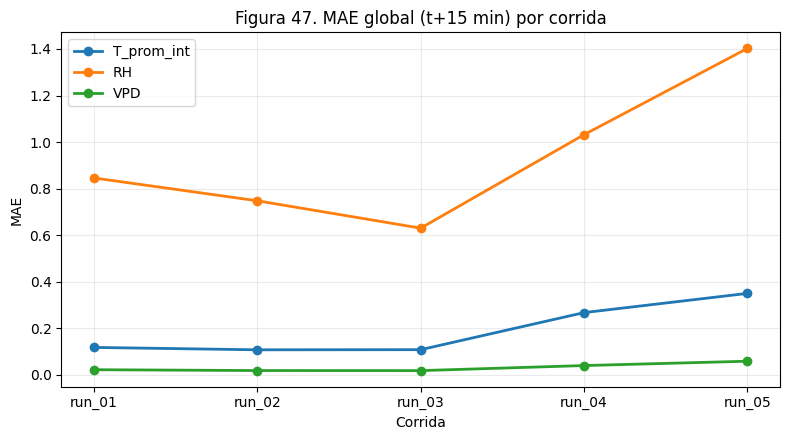

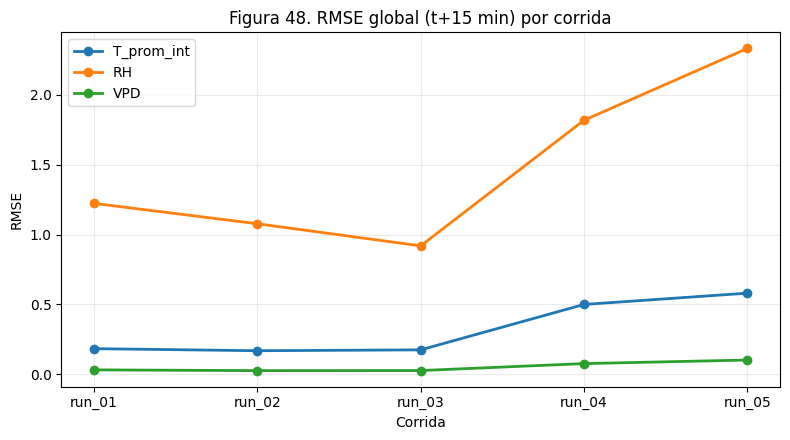

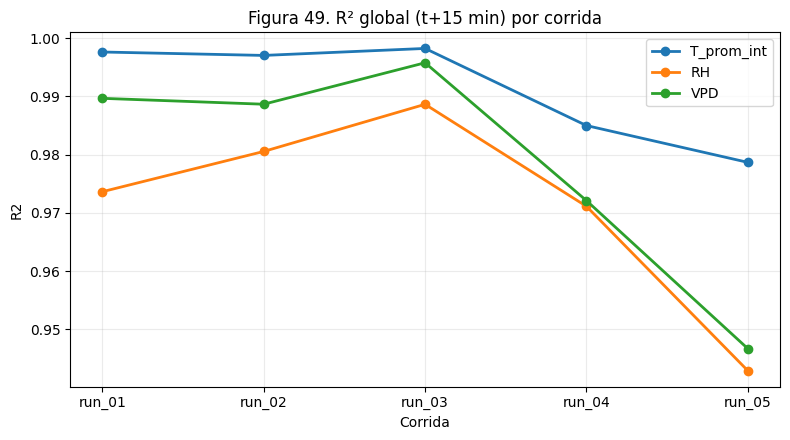

Figuras guardadas en resultados_cap5/:
 - figura_47_MAE_t15_por_corrida.png
 - figura_48_RMSE_t15_por_corrida.png
 - figura_49_R2_t15_por_corrida.png


In [ ]:
# ============================================================
# 5.2) Desempeño predictivo global (t+15 min)
#      - Tabla 11: métricas por corrida + media y DE
#      - Figuras 47-49: MAE/RMSE/R2 por corrida (T, RH, VPD)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Entradas (ya generadas por tu código 5.1) ----------
ruta_global_5 = "resultados_cap5/tabla_global_5corridas.csv"
ruta_media_std = "resultados_cap5/tabla_global_media_std.csv"

df_global_5 = pd.read_csv(ruta_global_5, index_col=0)
df_media_std = pd.read_csv(ruta_media_std, index_col=0)

# Columnas de corridas (run_01..run_05)
cols_runs = [c for c in df_global_5.columns if str(c).startswith("run_")]
cols_runs = sorted(cols_runs)

# ---------- Métricas predictivas de interés (t+15) ----------
metricas_pred = [
    "T_prom_int_MAE", "T_prom_int_RMSE", "T_prom_int_R2",
    "RH_MAE", "RH_RMSE", "RH_R2",
    "VPD_MAE", "VPD_RMSE", "VPD_R2"
]

# ---------- Construir Tabla 11 (por corrida + media y DE) ----------
tabla_11 = df_global_5.loc[metricas_pred, cols_runs].copy()
tabla_11["media"] = df_media_std.loc[metricas_pred, "media"].values
tabla_11["std"] = df_media_std.loc[metricas_pred, "std"].values

# Redondeo (R2 con más decimales)
def _redondear_fila(nombre_metrica: str, fila: pd.Series) -> pd.Series:
    if "R2" in nombre_metrica:
        return fila.round(6)
    return fila.round(6)

tabla_11 = tabla_11.apply(lambda col: col, axis=0)
tabla_11 = tabla_11.apply(lambda fila: _redondear_fila(fila.name, fila), axis=1)

# Guardar Tabla 11
os.makedirs("resultados_cap5", exist_ok=True)
tabla_11.to_csv("resultados_cap5/tabla_11_desempeno_predictivo_t15.csv")

# También en Excel (útil para pegar directo a Word)
with pd.ExcelWriter("resultados_cap5/tabla_11_desempeno_predictivo_t15.xlsx") as writer:
    tabla_11.to_excel(writer, sheet_name="Tabla_11")

print("Generado:")
print(" - resultados_cap5/tabla_11_desempeno_predictivo_t15.csv")
print(" - resultados_cap5/tabla_11_desempeno_predictivo_t15.xlsx")
display(tabla_11)

# ============================================================
# Figuras 47-49 (MAE, RMSE, R2 por corrida)
# ============================================================

# Helper para graficar una métrica (MAE/RMSE/R2)
def graficar_metricas_por_corrida(nombre_figura: str, metrica_suffix: str, ruta_png: str):
    # Series por variable
    y_T = df_global_5.loc[f"T_prom_int_{metrica_suffix}", cols_runs].astype(float).values
    y_RH = df_global_5.loc[f"RH_{metrica_suffix}", cols_runs].astype(float).values
    y_VPD = df_global_5.loc[f"VPD_{metrica_suffix}", cols_runs].astype(float).values

    plt.figure(figsize=(8, 4.5))
    plt.plot(cols_runs, y_T, marker="o", linewidth=2, label="T_prom_int")
    plt.plot(cols_runs, y_RH, marker="o", linewidth=2, label="RH")
    plt.plot(cols_runs, y_VPD, marker="o", linewidth=2, label="VPD")
    plt.xlabel("Corrida")
    plt.ylabel(metrica_suffix)
    plt.title(nombre_figura)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(ruta_png, dpi=300)
    plt.show()

# Figura 47: MAE
graficar_metricas_por_corrida(
    nombre_figura="Figura 47. MAE global (t+15 min) por corrida",
    metrica_suffix="MAE",
    ruta_png="resultados_cap5/figura_47_MAE_t15_por_corrida.png"
)

# Figura 48: RMSE
graficar_metricas_por_corrida(
    nombre_figura="Figura 48. RMSE global (t+15 min) por corrida",
    metrica_suffix="RMSE",
    ruta_png="resultados_cap5/figura_48_RMSE_t15_por_corrida.png"
)

# Figura 49: R2
graficar_metricas_por_corrida(
    nombre_figura="Figura 49. R² global (t+15 min) por corrida",
    metrica_suffix="R2",
    ruta_png="resultados_cap5/figura_49_R2_t15_por_corrida.png"
)

print("Figuras guardadas en resultados_cap5/:")
print(" - figura_47_MAE_t15_por_corrida.png")
print(" - figura_48_RMSE_t15_por_corrida.png")
print(" - figura_49_R2_t15_por_corrida.png")


Generado:
 - resultados_cap5/tabla_12_guardas_higrometricas.csv
 - resultados_cap5/tabla_12_guardas_higrometricas.xlsx


,corrida,n_filas,n_bloqueo_cond,pct_bloqueo_cond,n_precaucion_humedad,pct_precaucion_humedad
0,run_01,1000,0,0.0,114,11.4
1,run_02,1000,0,0.0,217,21.7
2,run_03,1000,0,0.0,0,0.0
3,run_04,1000,0,0.0,176,17.6
4,run_05,1000,0,0.0,63,6.3


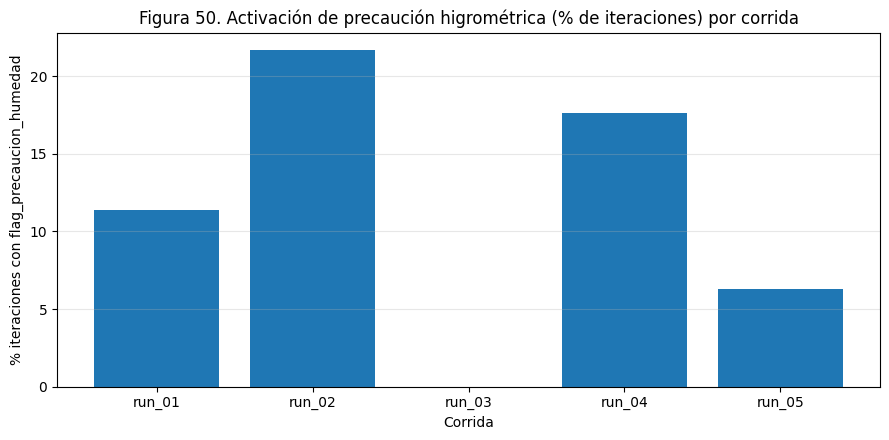

Generado: resultados_cap5/figura_50_precaucion_higrometrica_pct_por_corrida.png
Generado:
 - resultados_cap5/tabla_13_guardas_por_dia_noche.csv
 - resultados_cap5/tabla_13_guardas_por_dia_noche.xlsx


,corrida,cond_dia_noche,n_iter,n_bloqueo_cond,pct_bloqueo_cond,n_precaucion_humedad,pct_precaucion_humedad
0,run_01,Dia,438,0,0.0,114,26.027397
1,run_01,Noche,562,0,0.0,0,0.000000
2,run_02,Dia,478,0,0.0,217,45.397490
3,run_02,Noche,522,0,0.0,0,0.000000
4,run_03,Dia,410,0,0.0,0,0.000000
5,run_03,Noche,590,0,0.0,0,0.000000
6,run_04,Dia,455,0,0.0,176,38.681319
7,run_04,Noche,545,0,0.0,0,0.000000
8,run_05,Dia,495,0,0.0,63,12.727273
9,run_05,Noche,505,0,0.0,0,0.000000


In [ ]:
# ============================================================
# 5.3) Guardas higrométricas (bloqueo/precaución) en 5 corridas
#      - Tabla 12: conteos y porcentajes por corrida (desde resumen_global.csv)
#      - Figura 50: % precaución por corrida
#      - Tabla 13: desglose por día/noche (desde replay_sombra_historico.csv)
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Configuración ----------
carpeta_base = "resultados_fase5_5corridas"
carpeta_salida = "resultados_cap5"
os.makedirs(carpeta_salida, exist_ok=True)

# ---------- Localizar carpetas run_XX ----------
carpetas = sorted([
    os.path.join(carpeta_base, d) for d in os.listdir(carpeta_base)
    if os.path.isdir(os.path.join(carpeta_base, d)) and d.startswith("run_")
])

if len(carpetas) == 0:
    raise FileNotFoundError(f"No se encontraron carpetas run_XX en: {carpeta_base}")

# ============================================================
# (A) TABLA 12: Guardas por corrida (desde resumen_global.csv)
# ============================================================

filas_guardas = []

for p in carpetas:
    corrida = os.path.basename(p)

    ruta_rg = os.path.join(p, "resumen_global.csv")
    if not os.path.exists(ruta_rg):
        continue

    df_rg = pd.read_csv(ruta_rg, header=None, names=["metrica", "valor"])
    s = pd.Series(df_rg["valor"].values, index=df_rg["metrica"].astype(str).values)
    s = pd.to_numeric(s, errors="coerce")

    n_filas = float(s.get("n_filas", np.nan))
    n_bloqueo = float(s.get("n_bloqueo_cond", np.nan))
    n_precaucion = float(s.get("n_precaucion_humedad", np.nan))

    pct_bloqueo = np.nan
    pct_precaucion = np.nan
    if np.isfinite(n_filas) and n_filas > 0:
        pct_bloqueo = 100.0 * (n_bloqueo / n_filas) if np.isfinite(n_bloqueo) else np.nan
        pct_precaucion = 100.0 * (n_precaucion / n_filas) if np.isfinite(n_precaucion) else np.nan

    filas_guardas.append({
        "corrida": corrida,
        "n_filas": int(n_filas) if np.isfinite(n_filas) else np.nan,
        "n_bloqueo_cond": int(n_bloqueo) if np.isfinite(n_bloqueo) else np.nan,
        "pct_bloqueo_cond": pct_bloqueo,
        "n_precaucion_humedad": int(n_precaucion) if np.isfinite(n_precaucion) else np.nan,
        "pct_precaucion_humedad": pct_precaucion
    })

df_tabla_12 = pd.DataFrame(filas_guardas).sort_values("corrida").reset_index(drop=True)

ruta_tabla_12_csv = os.path.join(carpeta_salida, "tabla_12_guardas_higrometricas.csv")
ruta_tabla_12_xlsx = os.path.join(carpeta_salida, "tabla_12_guardas_higrometricas.xlsx")
df_tabla_12.to_csv(ruta_tabla_12_csv, index=False)
df_tabla_12.to_excel(ruta_tabla_12_xlsx, index=False)

print("Generado:")
print(f" - {ruta_tabla_12_csv}")
print(f" - {ruta_tabla_12_xlsx}")
display(df_tabla_12)

# ============================================================
# (B) FIGURA 50: % de precaución por corrida
# ============================================================

fig = plt.figure(figsize=(9, 4.5))
plt.bar(df_tabla_12["corrida"], df_tabla_12["pct_precaucion_humedad"])
plt.title("Figura 50. Activación de precaución higrométrica (% de iteraciones) por corrida")
plt.xlabel("Corrida")
plt.ylabel("% iteraciones con flag_precaucion_humedad")
plt.grid(True, axis="y", alpha=0.3)

ruta_fig_50 = os.path.join(carpeta_salida, "figura_50_precaucion_higrometrica_pct_por_corrida.png")
plt.tight_layout()
plt.savefig(ruta_fig_50, dpi=200)
plt.show()

print(f"Generado: {ruta_fig_50}")

# ============================================================
# (C) TABLA 13: Guardas por corrida y día/noche (rec_esDia)
#     desde replay_sombra_historico.csv
# ============================================================

filas_dia_noche = []

for p in carpetas:
    corrida = os.path.basename(p)
    ruta_replay = os.path.join(p, "replay_sombra_historico.csv")
    if not os.path.exists(ruta_replay):
        continue

    df_r = pd.read_csv(ruta_replay)

    # Normalizar columnas esperadas
    if "rec_esDia" not in df_r.columns:
        df_r["rec_esDia"] = np.nan
    if "flag_bloqueo_cond" not in df_r.columns:
        df_r["flag_bloqueo_cond"] = 0
    if "flag_precaucion_humedad" not in df_r.columns:
        df_r["flag_precaucion_humedad"] = 0

    # rec_esDia puede venir como bool, texto o NaN
    # Convertir a etiquetas estables: Dia / Noche / NA
    def _map_esdia(x):
        if pd.isna(x):
            return "NA"
        if isinstance(x, (bool, np.bool_)):
            return "Dia" if x else "Noche"
        xs = str(x).strip().lower()
        if xs in ["true", "1", "dia", "day"]:
            return "Dia"
        if xs in ["false", "0", "noche", "night"]:
            return "Noche"
        return "NA"

    df_r["cond_dia_noche"] = df_r["rec_esDia"].apply(_map_esdia)

    # Asegurar numéricos
    df_r["flag_bloqueo_cond"] = pd.to_numeric(df_r["flag_bloqueo_cond"], errors="coerce").fillna(0).astype(int)
    df_r["flag_precaucion_humedad"] = pd.to_numeric(df_r["flag_precaucion_humedad"], errors="coerce").fillna(0).astype(int)

    g = (
        df_r
        .groupby("cond_dia_noche", dropna=False)
        .agg(
            n_iter=("cond_dia_noche", "count"),
            n_bloqueo_cond=("flag_bloqueo_cond", "sum"),
            n_precaucion_humedad=("flag_precaucion_humedad", "sum")
        )
        .reset_index()
    )

    # porcentajes por subconjunto
    g["pct_bloqueo_cond"] = 100.0 * g["n_bloqueo_cond"] / g["n_iter"]
    g["pct_precaucion_humedad"] = 100.0 * g["n_precaucion_humedad"] / g["n_iter"]

    for _, row in g.iterrows():
        filas_dia_noche.append({
            "corrida": corrida,
            "cond_dia_noche": row["cond_dia_noche"],
            "n_iter": int(row["n_iter"]),
            "n_bloqueo_cond": int(row["n_bloqueo_cond"]),
            "pct_bloqueo_cond": float(row["pct_bloqueo_cond"]),
            "n_precaucion_humedad": int(row["n_precaucion_humedad"]),
            "pct_precaucion_humedad": float(row["pct_precaucion_humedad"])
        })

df_tabla_13 = pd.DataFrame(filas_dia_noche).sort_values(["corrida", "cond_dia_noche"]).reset_index(drop=True)

ruta_tabla_13_csv = os.path.join(carpeta_salida, "tabla_13_guardas_por_dia_noche.csv")
ruta_tabla_13_xlsx = os.path.join(carpeta_salida, "tabla_13_guardas_por_dia_noche.xlsx")
df_tabla_13.to_csv(ruta_tabla_13_csv, index=False)
df_tabla_13.to_excel(ruta_tabla_13_xlsx, index=False)

print("Generado:")
print(f" - {ruta_tabla_13_csv}")
print(f" - {ruta_tabla_13_xlsx}")
display(df_tabla_13)


Generado:
 - resultados_cap5/tabla_14_duty_prom_actuadores.csv
 - resultados_cap5/tabla_14_duty_prom_actuadores.xlsx
 - resultados_cap5/tabla_15_conmutaciones_actuadores.csv
 - resultados_cap5/tabla_15_conmutaciones_actuadores.xlsx


,run_01,run_02,run_03,run_04,run_05,media,std
A1,0.081417,0.006833,0.095533,0.119988,0.133536,0.087461,0.049456
A2,0.069917,0.000000,0.088700,0.110988,0.127369,0.079395,0.049446
A3,0.041250,0.000000,0.070700,0.096321,0.108036,0.063261,0.043702
A4,0.020250,0.000000,0.049200,0.069321,0.071036,0.041961,0.031139
A5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,run_01,run_02,run_03,run_04,run_05,media,std
A1,13.0,18.0,8.0,13.0,14.0,13.2,3.563706
A2,9.0,0.0,12.0,11.0,18.0,10.0,6.519202
A3,19.0,0.0,16.0,17.0,16.0,13.6,7.700649
A4,9.0,0.0,12.0,34.0,48.0,20.6,19.768662
A5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
A6,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
A7,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
A8,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
A9,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
A10,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


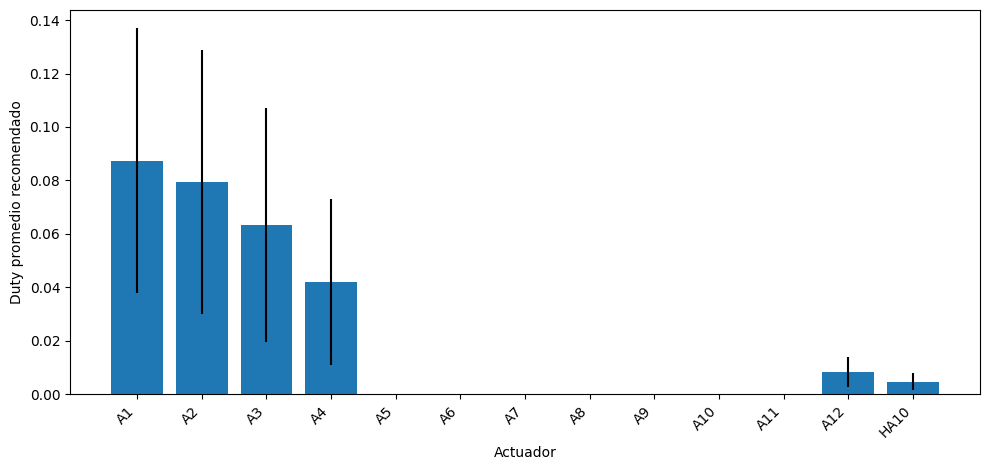

Generado: resultados_cap5/figura_51_duty_prom_media_std_por_actuador.png


In [ ]:
# ============================================================
# 5.4) Actuación recomendada (TODOS los actuadores existentes)
#      - Consolidar desde resumen_global.csv de las 5 corridas
#      - Tabla duty_prom por actuador × corrida + media/std
#      - Tabla conmutaciones por actuador × corrida + media/std
#      - Figura: duty_prom (media ± std) por actuador (todos)
# ============================================================


import re


carpeta_base = "resultados_fase5_5corridas"
carpeta_salida = "resultados_cap5"
os.makedirs(carpeta_salida, exist_ok=True)

# ---------- Detectar corridas ----------
carpetas_run = sorted([
    os.path.join(carpeta_base, d) for d in os.listdir(carpeta_base)
    if os.path.isdir(os.path.join(carpeta_base, d)) and d.startswith("run_")
])

# ---------- Leer resumen_global.csv por corrida ----------
series_corridas = []
nombres_corridas = []

for carpeta in carpetas_run:
    ruta = os.path.join(carpeta, "resumen_global.csv")
    if not os.path.exists(ruta):
        continue

    df_rg = pd.read_csv(ruta, header=None, names=["metrica", "valor"])
    s = pd.Series(df_rg["valor"].values, index=df_rg["metrica"].astype(str).values)
    s = pd.to_numeric(s, errors="coerce")

    series_corridas.append(s)
    nombres_corridas.append(os.path.basename(carpeta))

if len(series_corridas) == 0:
    raise ValueError("No se encontraron archivos resumen_global.csv en las carpetas run_XX.")

df_global = pd.concat(series_corridas, axis=1)
df_global.columns = nombres_corridas

# ---------- Separar duty_prom y conmut ----------
df_duty = df_global.loc[df_global.index.str.startswith("duty_prom_")].copy()
df_conm = df_global.loc[df_global.index.str.startswith("conmut_")].copy()

# Etiquetas de actuador (quitar prefijo)
df_duty.index = df_duty.index.str.replace("duty_prom_", "", regex=False)
df_conm.index = df_conm.index.str.replace("conmut_", "", regex=False)

# ---------- Alinear conjuntos de actuadores (por si alguno aparece solo en una tabla) ----------
actuadores = sorted(set(df_duty.index).union(set(df_conm.index)))

df_duty = df_duty.reindex(actuadores)
df_conm = df_conm.reindex(actuadores)

# ---------- Orden natural (A1, A2, ..., A12, HA10, etc.) ----------
def _clave_orden_actuador(a: str):
    m = re.match(r"^A(\d+)$", str(a))
    if m:
        return (0, int(m.group(1)))
    m2 = re.match(r"^HA(\d+)$", str(a))
    if m2:
        return (1, int(m2.group(1)))
    return (2, str(a))

actuadores_ordenados = sorted(actuadores, key=_clave_orden_actuador)
df_duty = df_duty.reindex(actuadores_ordenados)
df_conm = df_conm.reindex(actuadores_ordenados)

# ---------- Agregar media y std (entre corridas) ----------
df_duty_out = df_duty.copy()
df_duty_out["media"] = df_duty.mean(axis=1)
df_duty_out["std"] = df_duty.std(axis=1, ddof=1)

df_conm_out = df_conm.copy()
df_conm_out["media"] = df_conm.mean(axis=1)
df_conm_out["std"] = df_conm.std(axis=1, ddof=1)

# ---------- Guardar tablas (CSV y XLSX) ----------
ruta_tabla_14_csv = os.path.join(carpeta_salida, "tabla_14_duty_prom_actuadores.csv")
ruta_tabla_15_csv = os.path.join(carpeta_salida, "tabla_15_conmutaciones_actuadores.csv")
ruta_tabla_14_xlsx = os.path.join(carpeta_salida, "tabla_14_duty_prom_actuadores.xlsx")
ruta_tabla_15_xlsx = os.path.join(carpeta_salida, "tabla_15_conmutaciones_actuadores.xlsx")

df_duty_out.to_csv(ruta_tabla_14_csv)
df_conm_out.to_csv(ruta_tabla_15_csv)
df_duty_out.to_excel(ruta_tabla_14_xlsx)
df_conm_out.to_excel(ruta_tabla_15_xlsx)

print("Generado:")
print(" -", ruta_tabla_14_csv)
print(" -", ruta_tabla_14_xlsx)
print(" -", ruta_tabla_15_csv)
print(" -", ruta_tabla_15_xlsx)

display(df_duty_out)
display(df_conm_out)

# ---------- Figura 51: duty_prom (media ± std) por actuador (todos) ----------
df_plot = df_duty_out[["media", "std"]].copy()

n_act = len(df_plot)
ancho = max(10.0, 0.65 * n_act)
alto = 4.8

plt.figure(figsize=(ancho, alto))
plt.bar(df_plot.index.astype(str), df_plot["media"].values, yerr=df_plot["std"].values)
plt.ylabel("Duty promedio recomendado")
plt.xlabel("Actuador")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ruta_fig_51 = os.path.join(carpeta_salida, "figura_51_duty_prom_media_std_por_actuador.png")
plt.savefig(ruta_fig_51, dpi=200)
plt.show()

print("Generado:", ruta_fig_51)



Generado:
 - resultados_cap5/tabla_16_acuerdo_onoff_por_corrida.csv
 - resultados_cap5/tabla_17_acuerdo_onoff_resumen.csv


,corrida,actuador,n_valid,accuracy_onoff,tasa_ON_hist,tasa_ON_rec
0,run_01,A1,1000,0.902,0.140,0.224
1,run_01,A2,1000,0.945,0.112,0.155
2,run_01,A3,1000,0.972,0.069,0.069
3,run_01,A4,1000,0.981,0.032,0.027
4,run_01,A5,1000,1.000,0.000,0.000
5,run_01,A6,1000,1.000,0.000,0.000
6,run_01,A7,1000,1.000,0.000,0.000
7,run_01,A8,1000,1.000,0.000,0.000
8,run_01,A9,1000,1.000,0.000,0.000
9,run_01,A10,1000,1.000,0.000,0.000


,actuador,corridas_con_dato,accuracy_media,accuracy_std,n_valid_total,tasa_ON_hist_media,tasa_ON_rec_media
0,A1,5,0.9246,0.023512,5000,0.1278,0.1940
1,A10,5,0.9998,0.000447,5000,0.0002,0.0000
2,A11,5,0.9716,0.016697,5000,0.0284,0.0000
3,A12,5,0.9354,0.038135,5000,0.0486,0.0320
4,A2,5,0.9560,0.024890,5000,0.1104,0.1456
5,A3,5,0.9754,0.014241,5000,0.0874,0.0972
6,A4,5,0.9736,0.018823,5000,0.0570,0.0546
7,A5,5,0.9658,0.035160,5000,0.0342,0.0000
8,A6,5,0.9658,0.035160,5000,0.0342,0.0000
9,A7,5,0.9726,0.028077,5000,0.0274,0.0000


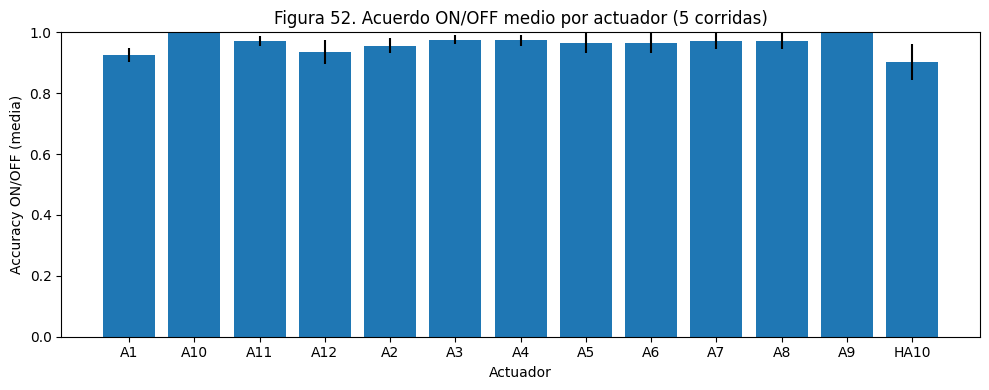

Generado: resultados_cap5/figura_52_acuerdo_onoff_medio_por_actuador.png


In [ ]:
# ============================================================
# 5.5) Comparación con operación histórica: acuerdo ON/OFF
#      - Lee replay_sombra_historico.csv de run_01..run_05
#      - Calcula accuracy ON/OFF, tasa ON hist/rec y n_valid
#      - Genera Tabla 16 (por corrida) y Tabla 17 (media±std)
#      - (Opcional) Figura 52: accuracy medio por actuador
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

carpeta_base = "resultados_fase5_5corridas"
carpetas = sorted([
    os.path.join(carpeta_base, d) for d in os.listdir(carpeta_base)
    if os.path.isdir(os.path.join(carpeta_base, d)) and d.startswith("run_")
])

actuadores = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10","A11","A12","HA10"]

filas = []

for carpeta in carpetas:
    corrida = os.path.basename(carpeta)
    ruta_replay = os.path.join(carpeta, "replay_sombra_historico.csv")
    if not os.path.exists(ruta_replay):
        continue

    df = pd.read_csv(ruta_replay)

    for a in actuadores:
        col_hist = f"hist_{a}"
        col_rec = f"rec_{a}_duty" if a != "HA10" else "rec_HA10_duty"

        if (col_hist not in df.columns) or (col_rec not in df.columns):
            # No hay columnas suficientes para comparar
            filas.append({
                "corrida": corrida,
                "actuador": a,
                "n_valid": 0,
                "accuracy_onoff": np.nan,
                "tasa_ON_hist": np.nan,
                "tasa_ON_rec": np.nan
            })
            continue

        h = pd.to_numeric(df[col_hist], errors="coerce")
        r = pd.to_numeric(df[col_rec], errors="coerce")

        # Pares válidos (evita NaN históricos y NaN recomendados)
        mask = np.isfinite(h.values) & np.isfinite(r.values)
        n_valid = int(mask.sum())

        if n_valid == 0:
            filas.append({
                "corrida": corrida,
                "actuador": a,
                "n_valid": 0,
                "accuracy_onoff": np.nan,
                "tasa_ON_hist": np.nan,
                "tasa_ON_rec": np.nan
            })
            continue

        h_on = (h[mask] > 0.0).astype(int)
        r_on = (r[mask] > 0.0).astype(int)

        acc = float((h_on.values == r_on.values).mean())

        filas.append({
            "corrida": corrida,
            "actuador": a,
            "n_valid": n_valid,
            "accuracy_onoff": acc,
            "tasa_ON_hist": float(h_on.mean()),
            "tasa_ON_rec": float(r_on.mean())
        })

df_acuerdo_all = pd.DataFrame(filas)

# Tabla 16: por corrida
os.makedirs("resultados_cap5", exist_ok=True)
df_acuerdo_all.to_csv("resultados_cap5/tabla_16_acuerdo_onoff_por_corrida.csv", index=False)

# Tabla 17: resumen por actuador (media±std del accuracy), solo donde haya datos
df_resumen = (
    df_acuerdo_all
    .groupby("actuador", dropna=False)
    .agg(
        corridas_con_dato=("accuracy_onoff", lambda s: int(np.isfinite(pd.to_numeric(s, errors="coerce")).sum())),
        accuracy_media=("accuracy_onoff", lambda s: float(np.nanmean(pd.to_numeric(s, errors="coerce")))),
        accuracy_std=("accuracy_onoff", lambda s: float(np.nanstd(pd.to_numeric(s, errors="coerce"), ddof=1))),
        n_valid_total=("n_valid", "sum"),
        tasa_ON_hist_media=("tasa_ON_hist", lambda s: float(np.nanmean(pd.to_numeric(s, errors="coerce")))),
        tasa_ON_rec_media=("tasa_ON_rec", lambda s: float(np.nanmean(pd.to_numeric(s, errors="coerce")))),
    )
    .reset_index()
)

df_resumen.to_csv("resultados_cap5/tabla_17_acuerdo_onoff_resumen.csv", index=False)

print("Generado:")
print(" - resultados_cap5/tabla_16_acuerdo_onoff_por_corrida.csv")
print(" - resultados_cap5/tabla_17_acuerdo_onoff_resumen.csv")

display(df_acuerdo_all.head(30))
display(df_resumen)

# ---------- Figura 52 (opcional): accuracy medio por actuador ----------
df_plot = df_resumen.copy()
df_plot = df_plot[np.isfinite(df_plot["accuracy_media"])].copy()

plt.figure(figsize=(10, 4))
plt.bar(df_plot["actuador"], df_plot["accuracy_media"], yerr=df_plot["accuracy_std"])
plt.ylim(0, 1.0)
plt.ylabel("Accuracy ON/OFF (media)")
plt.xlabel("Actuador")
plt.title("Figura 52. Acuerdo ON/OFF medio por actuador (5 corridas)")
plt.tight_layout()

ruta_fig = "resultados_cap5/figura_52_acuerdo_onoff_medio_por_actuador.png"
plt.savefig(ruta_fig, dpi=200)
plt.show()

print(f"Generado: {ruta_fig}")


Generado:
 - resultados_cap5/tabla_17_bandas_fisiologicas_historico_replay.xlsx
 - resultados_cap5/tabla_17_bandas_fisiologicas_historico_replay_resumen.csv


,variable,pct_en_banda_optima_t_media,pct_en_banda_optima_t_std,pct_en_banda_optima_gt_t15_media,pct_en_banda_optima_gt_t15_std,episodios_fuera_t_media,dur_fuera_media_min_t_media,episodios_fuera_gt_t15_media,dur_fuera_media_min_gt_t15_media
0,T,19.50,8.872993,19.34,8.654652,7.8,610.872222,7.8,592.421856
1,RH,66.86,8.126684,66.94,8.161066,23.2,106.086695,23.0,112.194589
2,VPD,44.34,5.147621,44.44,5.161686,18.0,217.724084,18.0,219.050450


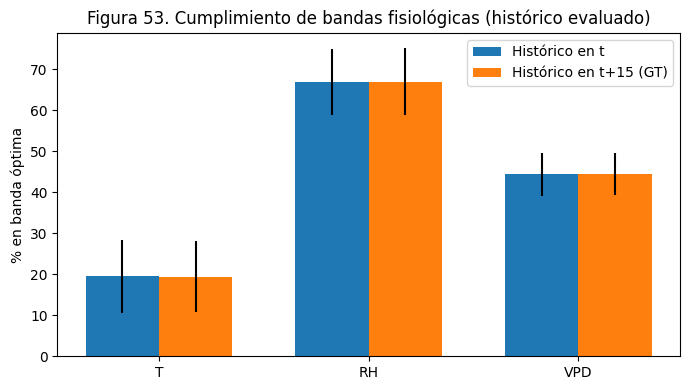

Generado: resultados_cap5/figura_53_pct_en_banda_optima_t_vs_gt_t15.png


In [ ]:
# ============================================================
# 5.6) Calcular cumplimiento de bandas fisiológicas en histórico evaluado
#      - Leer replay por corrida (run_01..run_05)
#      - Calcular % en banda óptima en t y en GT t+15
#      - Calcular episodios fuera de banda y duración
#      - Exportar Tabla 17 y Figura 53
# ============================================================


# ---------- Definir carpetas ----------
carpeta_runs = "resultados_fase5_5corridas"
carpeta_out = "resultados_cap5"
os.makedirs(carpeta_out, exist_ok=True)

runs = sorted([d for d in os.listdir(carpeta_runs) if d.startswith("run_")])

# ---------- Definir bandas óptimas ----------
def en_banda_optima_T(x):
    return np.isfinite(x) & (x >= 22.0) & (x <= 28.0)

def en_banda_optima_RH(x):
    return np.isfinite(x) & (x >= 60.0) & (x <= 80.0)

def en_banda_optima_VPD(x):
    return np.isfinite(x) & (x >= 0.4) & (x <= 0.8)

# ---------- Calcular episodios fuera de banda ----------
def calcular_episodios_fuera(mask_fuera: np.ndarray, dt_min: float):
    mask = mask_fuera.astype(bool)
    if mask.size == 0:
        return 0, np.nan, np.nan

    cambios = np.diff(mask.astype(int), prepend=0, append=0)
    inicios = np.where(cambios == 1)[0]
    fines = np.where(cambios == -1)[0]

    longitudes = (fines - inicios).astype(int)
    if longitudes.size == 0:
        return 0, np.nan, np.nan

    duraciones_min = longitudes * float(dt_min)
    return int(longitudes.size), float(np.mean(duraciones_min)), float(np.quantile(duraciones_min, 0.95))

# ---------- Definir columnas del replay ----------
col_t = {"T": "med_T_prom_int", "RH": "med_RH", "VPD": "med_VPD"}
col_gt = {"T": "gt_T_prom_int_t+15", "RH": "gt_RH_t+15", "VPD": "gt_VPD_t+15"}

filas = []

for r in runs:
    ruta_replay = os.path.join(carpeta_runs, r, "replay_sombra_historico.csv")
    df = pd.read_csv(ruta_replay)

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df = df.sort_values("fecha").reset_index(drop=True)

    dt_min = float(df["fecha"].diff().dt.total_seconds().median() / 60.0)
    if not np.isfinite(dt_min) or dt_min <= 0:
        dt_min = 5.0

    for var in ["T", "RH", "VPD"]:
        x_t = pd.to_numeric(df[col_t[var]], errors="coerce").values
        x_gt = pd.to_numeric(df[col_gt[var]], errors="coerce").values

        if var == "T":
            en_t = en_banda_optima_T(x_t)
            en_gt = en_banda_optima_T(x_gt)
        elif var == "RH":
            en_t = en_banda_optima_RH(x_t)
            en_gt = en_banda_optima_RH(x_gt)
        else:
            en_t = en_banda_optima_VPD(x_t)
            en_gt = en_banda_optima_VPD(x_gt)

        pct_en_t = float(100.0 * np.mean(en_t)) if en_t.size > 0 else np.nan
        pct_en_gt = float(100.0 * np.mean(en_gt)) if en_gt.size > 0 else np.nan

        n_ep_t, dur_media_t, dur_p95_t = calcular_episodios_fuera(~en_t, dt_min)
        n_ep_gt, dur_media_gt, dur_p95_gt = calcular_episodios_fuera(~en_gt, dt_min)

        filas.append({
            "corrida": r,
            "variable": var,
            "dt_min_medido": dt_min,
            "pct_en_banda_optima_t": pct_en_t,
            "pct_en_banda_optima_gt_t15": pct_en_gt,
            "episodios_fuera_t": n_ep_t,
            "dur_fuera_media_min_t": dur_media_t,
            "dur_fuera_p95_min_t": dur_p95_t,
            "episodios_fuera_gt_t15": n_ep_gt,
            "dur_fuera_media_min_gt_t15": dur_media_gt,
            "dur_fuera_p95_min_gt_t15": dur_p95_gt
        })

df_por_corrida = pd.DataFrame(filas)

# ---------- Construir resumen (Tabla 17 para Word) ----------
df_tabla17 = (
    df_por_corrida
    .groupby("variable", as_index=False)
    .agg(
        pct_en_banda_optima_t_media=("pct_en_banda_optima_t", "mean"),
        pct_en_banda_optima_t_std=("pct_en_banda_optima_t", "std"),
        pct_en_banda_optima_gt_t15_media=("pct_en_banda_optima_gt_t15", "mean"),
        pct_en_banda_optima_gt_t15_std=("pct_en_banda_optima_gt_t15", "std"),
        episodios_fuera_t_media=("episodios_fuera_t", "mean"),
        dur_fuera_media_min_t_media=("dur_fuera_media_min_t", "mean"),
        episodios_fuera_gt_t15_media=("episodios_fuera_gt_t15", "mean"),
        dur_fuera_media_min_gt_t15_media=("dur_fuera_media_min_gt_t15", "mean"),
    )
)
df_tabla17["variable"] = pd.Categorical(df_tabla17["variable"], categories=["T","RH","VPD"], ordered=True)
df_tabla17 = df_tabla17.sort_values("variable").reset_index(drop=True)


# ---------- Exportar Tabla 17 ----------
ruta_xlsx = os.path.join(carpeta_out, "tabla_17_bandas_fisiologicas_historico_replay.xlsx")
ruta_csv = os.path.join(carpeta_out, "tabla_17_bandas_fisiologicas_historico_replay_resumen.csv")

with pd.ExcelWriter(ruta_xlsx) as writer:
    df_por_corrida.to_excel(writer, sheet_name="por_corrida", index=False)
    df_tabla17.to_excel(writer, sheet_name="resumen_media_std", index=False)

df_tabla17.to_csv(ruta_csv, index=False)

print("Generado:")
print(" -", ruta_xlsx)
print(" -", ruta_csv)

display(df_tabla17)

# ---------- Generar Figura 53 ----------
orden = ["T", "RH", "VPD"]
dfp = df_tabla17.set_index("variable").reindex(orden).reset_index()

x = np.arange(len(dfp))
w = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - w/2, dfp["pct_en_banda_optima_t_media"].values, width=w, yerr=dfp["pct_en_banda_optima_t_std"].values, label="Histórico en t")
plt.bar(x + w/2, dfp["pct_en_banda_optima_gt_t15_media"].values, width=w, yerr=dfp["pct_en_banda_optima_gt_t15_std"].values, label="Histórico en t+15 (GT)")
plt.xticks(x, dfp["variable"].values)
plt.ylabel("% en banda óptima")
plt.title("Figura 53. Cumplimiento de bandas fisiológicas (histórico evaluado)")
plt.legend()
plt.tight_layout()

ruta_fig = os.path.join(carpeta_out, "figura_53_pct_en_banda_optima_t_vs_gt_t15.png")
plt.savefig(ruta_fig, dpi=200)
plt.show()

print("Generado:", ruta_fig)


In [ ]:
# ============================================================
# 5.7) Generar Tabla 18 corta: archivos clave + agrupación por corrida
#      - Listar artefactos consolidados usados en el Cap. 5
#      - Agrupar archivos por corrida en una sola fila (run_*)
# ============================================================

import os
import pandas as pd

# ---------- Definir rutas base ----------
carpeta_cap5 = "resultados_cap5"
carpeta_runs = "resultados_fase5_5corridas"
os.makedirs(carpeta_cap5, exist_ok=True)

filas = []

# ---------- Definir función para agregar solo si existe ----------
def agregar_si_existe(nombre_archivo: str, descripcion: str, uso: str) -> None:
    ruta = os.path.join(carpeta_cap5, nombre_archivo)
    if os.path.exists(ruta):
        filas.append({
            "archivo": nombre_archivo,
            "ubicacion": f"{carpeta_cap5}/",
            "descripcion": descripcion,
            "uso_en_capitulo": uso
        })

# ---------- Registrar artefactos consolidados ----------
agregar_si_existe(
    "bitacora_5corridas.csv",
    "Bitácora de corridas: ventanas temporales, tamaño del segmento y tamaño del replay.",
    "Sección 5.1 / Tabla 10"
)

agregar_si_existe(
    "tabla_11_desempeno_predictivo_t15.xlsx",
    "Métricas predictivas t+15 min por corrida + media y desviación estándar.",
    "Sección 5.2 / Tabla 11"
)

agregar_si_existe(
    "figura_47_MAE_t15_por_corrida.png",
    "MAE global (t+15 min) por corrida para T_prom_int, RH y VPD.",
    "Sección 5.2 / Figura 47"
)

agregar_si_existe(
    "figura_50_precaucion_higrometrica_pct_por_corrida.png",
    "Porcentaje de activación de precaución higrométrica por corrida.",
    "Sección 5.3 / Figura 50"
)

agregar_si_existe(
    "tabla_12_guardas_higrometricas.xlsx",
    "Conteo y porcentaje de guardas higrométricas por corrida.",
    "Sección 5.3 / Tabla 12"
)

agregar_si_existe(
    "tabla_13_guardas_por_dia_noche.xlsx",
    "Desglose de guardas por corrida y condición día/noche.",
    "Sección 5.3 / Tabla 13"
)

agregar_si_existe(
    "tabla_14_duty_prom_actuadores.xlsx",
    "Duty promedio recomendado por actuador (A1–A12, HA10) por corrida + media y desviación estándar.",
    "Sección 5.4 / Tabla 14"
)

agregar_si_existe(
    "tabla_15_conmutaciones_actuadores.xlsx",
    "Conmutaciones ON/OFF por actuador (A1–A12, HA10) por corrida + media y desviación estándar.",
    "Sección 5.4 / Tabla 15"
)

# ---------- Registrar resumen ON/OFF por actuador (Tabla 16 en Word) ----------
# Aceptar cualquiera de los nombres usados durante la generación
for nombre_posible in [
    "tabla_17_acuerdo_onoff_resumen.csv",
    "tabla_16_acuerdo_onoff_resumen.csv",
    "tabla_16_acuerdo_onoff_resumen.xlsx",
    "tabla_17_acuerdo_onoff_resumen.xlsx",
]:
    agregar_si_existe(
        nombre_posible,
        "Resumen del acuerdo ON/OFF por actuador (media y desviación estándar; n_valid_total; tasas ON medias).",
        "Sección 5.5 / Tabla 16"
    )

agregar_si_existe(
    "figura_51_duty_prom_media_std_por_actuador.png",
    "Duty promedio recomendado por actuador (media ± desviación estándar).",
    "Sección 5.4 / Figura 51"
)

agregar_si_existe(
    "figura_52_acuerdo_onoff_medio_por_actuador.png",
    "Acuerdo ON/OFF medio por actuador (media ± desviación estándar).",
    "Sección 5.5 / Figura 52"
)

# ---------- Agregar fila agrupada de archivos por corrida ----------
filas.append({
    "archivo": "run_*/{replay_sombra_historico.csv, resumen_global.csv, resumen_por_escenarios.csv, resumen_acuerdo_actuadores.csv}",
    "ubicacion": f"{carpeta_runs}/",
    "descripcion": "Archivos generados por corrida: registro iteración a iteración del replay y resúmenes agregados por corrida.",
    "uso_en_capitulo": "Trazabilidad del experimento (corridas run_01–run_05)"
})

# ---------- Construir y guardar Tabla 17 corta ----------
df_tabla17_corta = pd.DataFrame(filas)

ruta_csv = os.path.join(carpeta_cap5, "tabla_17_archivos_resultados_generados_corta.csv")
ruta_xlsx = os.path.join(carpeta_cap5, "tabla_17_archivos_resultados_generados_corta.xlsx")

df_tabla17_corta.to_csv(ruta_csv, index=False)
df_tabla17_corta.to_excel(ruta_xlsx, index=False)

print("Generado:")
print(" -", ruta_csv)
print(" -", ruta_xlsx)

display(df_tabla17_corta)



Generado:
 - resultados_cap5/tabla_17_archivos_resultados_generados_corta.csv
 - resultados_cap5/tabla_17_archivos_resultados_generados_corta.xlsx


,archivo,ubicacion,descripcion,uso_en_capitulo
0,bitacora_5corridas.csv,resultados_cap5/,"Bitácora de corridas: ventanas temporales, tam...",Sección 5.1 / Tabla 10
1,tabla_11_desempeno_predictivo_t15.xlsx,resultados_cap5/,Métricas predictivas t+15 min por corrida + me...,Sección 5.2 / Tabla 11
2,figura_47_MAE_t15_por_corrida.png,resultados_cap5/,MAE global (t+15 min) por corrida para T_prom_...,Sección 5.2 / Figura 47
3,figura_50_precaucion_higrometrica_pct_por_corr...,resultados_cap5/,Porcentaje de activación de precaución higromé...,Sección 5.3 / Figura 50
4,tabla_12_guardas_higrometricas.xlsx,resultados_cap5/,Conteo y porcentaje de guardas higrométricas p...,Sección 5.3 / Tabla 12
5,tabla_13_guardas_por_dia_noche.xlsx,resultados_cap5/,Desglose de guardas por corrida y condición dí...,Sección 5.3 / Tabla 13
6,tabla_14_duty_prom_actuadores.xlsx,resultados_cap5/,Duty promedio recomendado por actuador (A1–A12...,Sección 5.4 / Tabla 14
7,tabla_15_conmutaciones_actuadores.xlsx,resultados_cap5/,"Conmutaciones ON/OFF por actuador (A1–A12, HA1...",Sección 5.4 / Tabla 15
8,tabla_17_acuerdo_onoff_resumen.csv,resultados_cap5/,Resumen del acuerdo ON/OFF por actuador (media...,Sección 5.5 / Tabla 16
9,figura_51_duty_prom_media_std_por_actuador.png,resultados_cap5/,Duty promedio recomendado por actuador (media ...,Sección 5.4 / Figura 51


In [ ]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# Configuración (ajustar si cambian rutas)
# =========================
carpeta_cap5 = Path("resultados_cap5")
carpeta_runs = Path("resultados_fase5_5corridas")

ruta_duty_rec = carpeta_cap5 / "tabla_14_duty_prom_actuadores.csv"
ruta_acuerdo_por_corrida = carpeta_cap5 / "tabla_16_acuerdo_onoff_por_corrida.csv"

# Potencias nominales (kW)
potencia_kw = {f"A{i}": 0.05 for i in range(1, 11)}  # A1-A10
potencia_kw["A11"] = 0.15
potencia_kw["A12"] = 0.30  # 2 ventiladores simultáneos
potencia_kw["HA10"] = 0.44 # bomba 120V, In=4.6A, FP~0.8

# Actuadores considerados (los que aparecen en tus tablas)
actuadores = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10","A11","A12","HA10"]

# =========================
# 1) Cargar duty recomendado (Tabla 14)
# =========================
duty_rec = pd.read_csv(ruta_duty_rec, index_col=0)
cols_corridas = [c for c in duty_rec.columns if str(c).startswith("run_")]
cols_corridas = sorted(cols_corridas)

# Filtrar solo actuadores de interés (por si hay extra)
duty_rec = duty_rec.reindex(actuadores)

# =========================
# 2) Cargar acuerdo ON/OFF por corrida (Tabla 16) y construir duty histórico
# =========================
df_acuerdo = pd.read_csv(ruta_acuerdo_por_corrida)

# Esperado por tu código 5.5: columnas corrida, actuador, tasa_ON_hist, tasa_ON_rec, accuracy_onoff...
cols_req = {"corrida","actuador","tasa_ON_hist"}
faltan = cols_req - set(df_acuerdo.columns)
if faltan:
    raise ValueError(f"Faltan columnas en {ruta_acuerdo_por_corrida}: {faltan}")

# Pivot: filas=actuador, columnas=corrida, valores=tasa_ON_hist
duty_hist = (
    df_acuerdo.pivot_table(index="actuador", columns="corrida", values="tasa_ON_hist", aggfunc="mean")
    .reindex(index=actuadores)
)

# Alinear corridas con Tabla 14 (si hay corridas faltantes)
duty_hist = duty_hist.reindex(columns=cols_corridas)

# Guardar duty histórico por corrida (útil para anexos / trazabilidad)
duty_hist_out = duty_hist.copy()
duty_hist_out["media"] = duty_hist_out.mean(axis=1)
duty_hist_out["std"] = duty_hist_out.std(axis=1, ddof=1)

duty_hist_out.to_csv(carpeta_cap5 / "tabla_duty_hist_por_corrida.csv")
duty_hist_out.to_excel(carpeta_cap5 / "tabla_duty_hist_por_corrida.xlsx")

# =========================
# 3) Estimar duración T (h) por corrida desde replay_sombra_historico.csv
#    (mejor que asumir dt fijo)
# =========================
def duracion_h_desde_replay(carpeta_run: Path) -> float:
    ruta_replay = carpeta_run / "replay_sombra_historico.csv"
    if not ruta_replay.exists():
        return np.nan
    df = pd.read_csv(ruta_replay, usecols=["fecha"])
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df = df.dropna().sort_values("fecha")
    if len(df) < 2:
        return np.nan
    # duración real de la corrida en horas
    return float((df["fecha"].iloc[-1] - df["fecha"].iloc[0]).total_seconds() / 3600.0)

T_h = {}
for run in cols_corridas:
    carpeta_run = carpeta_runs / run
    T_h[run] = duracion_h_desde_replay(carpeta_run)

# =========================
# 4) Calcular Pbar y kWh por corrida (rec vs hist)
# =========================
def potencia_media_equivalente(tabla_duty: pd.DataFrame, run: str) -> float:
    total = 0.0
    for a in actuadores:
        if a in tabla_duty.index and run in tabla_duty.columns:
            d = float(tabla_duty.loc[a, run]) if pd.notna(tabla_duty.loc[a, run]) else 0.0
            if a in potencia_kw:
                total += potencia_kw[a] * d
    return float(total)

filas = []
for run in cols_corridas:
    T = T_h.get(run, np.nan)
    Pbar_rec = potencia_media_equivalente(duty_rec, run)
    Pbar_hist = potencia_media_equivalente(duty_hist, run)

    E_rec = Pbar_rec * T if np.isfinite(T) else np.nan
    E_hist = Pbar_hist * T if np.isfinite(T) else np.nan

    delta = E_rec - E_hist if np.isfinite(E_rec) and np.isfinite(E_hist) else np.nan
    delta_pct = (100.0 * delta / E_hist) if np.isfinite(delta) and (E_hist not in [0, np.nan]) and (E_hist > 0) else np.nan

    filas.append({
        "corrida": run,
        "T_h": T,
        "Pbar_rec_kW": Pbar_rec,
        "E_rec_kWh": E_rec,
        "Pbar_hist_kW": Pbar_hist,
        "E_hist_kWh": E_hist,
        "Delta_kWh": delta,
        "Delta_pct": delta_pct
    })

tabla_energia = pd.DataFrame(filas).sort_values("corrida").reset_index(drop=True)

# Guardar tabla final para pegar a Word
tabla_energia.to_csv(carpeta_cap5 / "tabla_consumo_kwh_por_corrida.csv", index=False)
tabla_energia.to_excel(carpeta_cap5 / "tabla_consumo_kwh_por_corrida.xlsx", index=False)

print("Listo. Archivos generados en resultados_cap5/:")
print(" - tabla_duty_hist_por_corrida.csv / .xlsx")
print(" - tabla_consumo_kwh_por_corrida.csv / .xlsx")
display(tabla_energia)

Listo. Archivos generados en resultados_cap5/:
 - tabla_duty_hist_por_corrida.csv / .xlsx
 - tabla_consumo_kwh_por_corrida.csv / .xlsx


,corrida,T_h,Pbar_rec_kW,E_rec_kWh,Pbar_hist_kW,E_hist_kWh,Delta_kWh,Delta_pct
0,run_01,84.733333,0.013757,1.165648,0.06674,5.655103,-4.489454,-79.387674
1,run_02,84.250000,0.000342,0.028785,0.01760,1.482800,-1.454015,-98.058712
2,run_03,141.250000,0.021049,2.973156,0.05489,7.753213,-4.780057,-61.652598
3,run_04,84.383333,0.026639,2.247912,0.04498,3.795562,-1.547651,-40.775265
4,run_05,84.433333,0.029389,2.481395,0.05370,4.534070,-2.052675,-45.272236


In [ ]:
# ============================================================
# Estimar consumo energético equivalente por corrida (recomendado vs histórico)
#   - Cargar duty recomendado (Tabla 14)
#   - Construir duty histórico por corrida (Tabla 16 detallada o resumen por run)
#   - Estimar ventana temporal efectiva por corrida desde replay
#   - Calcular potencia media equivalente y energía (kWh) por corrida
#   - Exportar tablas en resultados_cap5
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path

carpeta_cap5 = Path("resultados_cap5")
carpeta_runs = Path("resultados_fase5_5corridas")

carpeta_cap5.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1) Cargar duty recomendado (Tabla 14)
# ============================================================

def cargar_tabla14_duty(carpeta: Path) -> pd.DataFrame:
    rutas = [
        carpeta / "tabla_14_duty_prom_actuadores.xlsx",
        carpeta / "tabla_14_duty_prom_actuadores.csv",
    ]
    for r in rutas:
        if r.exists():
            if r.suffix.lower() == ".xlsx":
                df = pd.read_excel(r, index_col=0)
            else:
                df = pd.read_csv(r, index_col=0)
            return df
    raise FileNotFoundError("No encontrarse tabla_14_duty_prom_actuadores.xlsx/csv en resultados_cap5/.")

duty_rec = cargar_tabla14_duty(carpeta_cap5)

corridas = [c for c in duty_rec.columns if str(c).startswith("run_")]
if len(corridas) == 0:
    raise ValueError("No detectarse columnas run_XX en Tabla 14. Verificar formato de tabla_14_duty_prom_actuadores.")

# Normalizar índice de actuadores
duty_rec.index = duty_rec.index.astype(str).str.strip()

# ============================================================
# 2) Construir duty histórico por corrida
# ============================================================

def construir_duty_hist_desde_tabla16(carpeta: Path, corridas_esperadas: list) -> pd.DataFrame | None:
    ruta = carpeta / "tabla_16_acuerdo_onoff_por_corrida.csv"
    if not ruta.exists():
        return None

    df = pd.read_csv(ruta)
    df.columns = [str(c).strip() for c in df.columns]

    def elegir_col(cols_posibles):
        for c in cols_posibles:
            if c in df.columns:
                return c
        return None

    col_corrida = elegir_col(["corrida", "run"])
    col_act = elegir_col(["actuador", "actuator", "act"])
    col_hist = elegir_col(["tasa_ON_hist", "tasa_on_hist", "tasa_ON_hist_media"])

    if col_corrida is None or col_act is None or col_hist is None:
        return None

    df[col_corrida] = df[col_corrida].astype(str).str.strip()
    df[col_act] = df[col_act].astype(str).str.strip()

    duty_hist = (
        df.pivot_table(index=col_act, columns=col_corrida, values=col_hist, aggfunc="mean")
        .sort_index()
    )

    cols_comunes = [c for c in corridas_esperadas if c in duty_hist.columns]
    if len(cols_comunes) == 0:
        return None

    duty_hist = duty_hist[cols_comunes]
    duty_hist["media"] = duty_hist.mean(axis=1)
    duty_hist["std"] = duty_hist.std(axis=1, ddof=1)
    return duty_hist

def construir_duty_hist_desde_runs(carpeta_runs: Path, corridas_esperadas: list) -> pd.DataFrame:
    filas = []

    for run in corridas_esperadas:
        ruta = carpeta_runs / run / "resumen_acuerdo_actuadores.csv"
        if not ruta.exists():
            continue

        df = pd.read_csv(ruta)
        df.columns = [str(c).strip() for c in df.columns]

        def elegir_col(cols_posibles):
            for c in cols_posibles:
                if c in df.columns:
                    return c
            return None

        col_act = elegir_col(["actuador", "actuator", "act"])
        col_hist = elegir_col(["tasa_ON_hist", "tasa_on_hist", "on_hist", "rate_on_hist"])

        if col_act is None or col_hist is None:
            continue

        tmp = df[[col_act, col_hist]].copy()
        tmp["corrida"] = run
        tmp[col_act] = tmp[col_act].astype(str).str.strip()
        tmp[col_hist] = pd.to_numeric(tmp[col_hist], errors="coerce")
        filas.append(tmp.rename(columns={col_act: "actuador", col_hist: "tasa_ON_hist"}))

    if len(filas) == 0:
        raise FileNotFoundError("No encontrarse resumen_acuerdo_actuadores.csv en run_*/ o no detectarse columnas requeridas.")

    df_all = pd.concat(filas, axis=0, ignore_index=True)

    duty_hist = (
        df_all.pivot_table(index="actuador", columns="corrida", values="tasa_ON_hist", aggfunc="mean")
        .sort_index()
    )

    cols_comunes = [c for c in corridas_esperadas if c in duty_hist.columns]
    if len(cols_comunes) == 0:
        raise ValueError("No alinearse corridas run_XX entre Tabla 14 y resúmenes por run.")

    duty_hist = duty_hist[cols_comunes]
    duty_hist["media"] = duty_hist.mean(axis=1)
    duty_hist["std"] = duty_hist.std(axis=1, ddof=1)
    return duty_hist

duty_hist = construir_duty_hist_desde_tabla16(carpeta_cap5, corridas)

if duty_hist is None:
    if not carpeta_runs.exists():
        raise FileNotFoundError("No existir resultados_fase5_5corridas/. Regenerar corridas o verificar ruta.")
    duty_hist = construir_duty_hist_desde_runs(carpeta_runs, corridas)

# Guardar duty histórico
duty_hist.to_csv(carpeta_cap5 / "tabla_duty_hist_actuadores.csv")
duty_hist.to_excel(carpeta_cap5 / "tabla_duty_hist_actuadores.xlsx")

# ============================================================
# 3) Estimar T_h por corrida desde replay (n_filas y dt_med)
# ============================================================

def estimar_Th_por_corrida(carpeta_runs: Path, corridas_esperadas: list) -> pd.Series:
    Th = {}
    for run in corridas_esperadas:
        ruta = carpeta_runs / run / "replay_sombra_historico.csv"
        if not ruta.exists():
            continue

        df = pd.read_csv(ruta, usecols=["fecha"])
        df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
        df = df.dropna(subset=["fecha"]).sort_values("fecha").reset_index(drop=True)

        n = len(df)
        if n < 3:
            continue

        dt_min = float(df["fecha"].diff().dt.total_seconds().median() / 60.0)
        if not np.isfinite(dt_min) or dt_min <= 0:
            dt_min = 5.0

        Th[run] = (n * dt_min) / 60.0

    if len(Th) == 0:
        raise ValueError("No estimarse T_h. Verificar existencia de replay_sombra_historico.csv en run_*/.")
    return pd.Series(Th)

Th_h = estimar_Th_por_corrida(carpeta_runs, corridas)

# ============================================================
# 4) Calcular kWh equivalente por corrida (recomendado vs histórico)
# ============================================================

# Definir potencias por actuador (kW)
# Sustituir estos valores por especificaciones reales cuando estén disponibles.
potencia_kw = {f"A{i}": 0.05 for i in range(1, 11)}  # A1–A10
potencia_kw["A11"] = 0.15
potencia_kw["A12"] = 0.30
potencia_kw["HA10"] = 0.44

def potencia_media_equivalente(tabla_duty: pd.DataFrame, corridas_esperadas: list) -> pd.Series:
    Pbar = {}
    for run in corridas_esperadas:
        if run not in tabla_duty.columns:
            continue
        total = 0.0
        for act, duty in tabla_duty[run].items():
            act = str(act).strip()
            if act in potencia_kw:
                total += potencia_kw[act] * float(duty)
        Pbar[run] = total
    return pd.Series(Pbar)

# Alinear índices para evitar actuadores fuera de set
duty_rec_run = duty_rec[corridas].copy()
duty_hist_run = duty_hist[corridas].copy()

Pbar_rec = potencia_media_equivalente(duty_rec_run, corridas)
Pbar_hist = potencia_media_equivalente(duty_hist_run, corridas)

# Alinear series por corrida
idx_corr = sorted(set(Pbar_rec.index).intersection(set(Pbar_hist.index)).intersection(set(Th_h.index)))
if len(idx_corr) == 0:
    raise ValueError("No existir intersección de corridas entre duty recomendado, duty histórico y T_h.")

Pbar_rec = Pbar_rec.loc[idx_corr]
Pbar_hist = Pbar_hist.loc[idx_corr]
Th_h = Th_h.loc[idx_corr]

E_rec = Pbar_rec * Th_h
E_hist = Pbar_hist * Th_h

tabla_energia = pd.DataFrame({
    "T_h": Th_h,
    "Pbar_rec_kW": Pbar_rec,
    "E_rec_kWh": E_rec,
    "Pbar_hist_kW": Pbar_hist,
    "E_hist_kWh": E_hist,
})

tabla_energia["Delta_kWh"] = tabla_energia["E_rec_kWh"] - tabla_energia["E_hist_kWh"]
tabla_energia["Delta_pct"] = np.where(
    tabla_energia["E_hist_kWh"] > 0,
    100.0 * tabla_energia["Delta_kWh"] / tabla_energia["E_hist_kWh"],
    np.nan
)

tabla_energia.index.name = "corrida"

tabla_energia.to_csv(carpeta_cap5 / "tabla_consumo_kwh_por_corrida.csv")
tabla_energia.to_excel(carpeta_cap5 / "tabla_consumo_kwh_por_corrida.xlsx")

print(tabla_energia)
print("\nGenerado:")
print(" - resultados_cap5/tabla_duty_hist_actuadores.csv")
print(" - resultados_cap5/tabla_duty_hist_actuadores.xlsx")
print(" - resultados_cap5/tabla_consumo_kwh_por_corrida.csv")
print(" - resultados_cap5/tabla_consumo_kwh_por_corrida.xlsx")


               T_h  Pbar_rec_kW  E_rec_kWh  Pbar_hist_kW  E_hist_kWh  Delta_kWh  Delta_pct
corrida                                                                                   
run_01   83.333333     0.013757   1.146389       0.06674    5.561667  -4.415278 -79.387674
run_02   83.333333     0.000342   0.028472       0.01760    1.466667  -1.438194 -98.058712
run_03   83.333333     0.021049   1.754074       0.05489    4.574167  -2.820093 -61.652598
run_04   83.333333     0.026639   2.219940       0.04498    3.748333  -1.528393 -40.775265
run_05   83.333333     0.029389   2.449067       0.05370    4.475000  -2.025933 -45.272236

Generado:
 - resultados_cap5/tabla_duty_hist_actuadores.csv
 - resultados_cap5/tabla_duty_hist_actuadores.xlsx
 - resultados_cap5/tabla_consumo_kwh_por_corrida.csv
 - resultados_cap5/tabla_consumo_kwh_por_corrida.xlsx
